In [134]:
import pandas as pd
from google.cloud import bigquery
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 1.Loading Data

In [ ]:
query = """

"""

**Observation**   
The 'SQL Query' that loads the Data from BigQuery has some levels of  obfuscation and will be kept private

In [136]:
#Querying raw data from bigquery
client = bigquery.Client()
df = client.query(query).to_dataframe()
df.shape

(535, 12)

## 2.Data Obfuscation
Obfuscation is the practice of making information difficult for humans or unauthorized tools to understand, and is often used to protect intellectual property or add a layer of "security by obscurity."
The following technics were studied and selected to protect copy rights and intellectual property.

#### Numeric Data Obfuscation Using Laplace Noise

### Overview
This dataset applies **Laplace noise obfuscation** to numeric fields in order to reduce the risk of sensitive information disclosure while preserving overall statistical utility. The method is inspired by the Laplace mechanism commonly used in differential privacy and is applied here as a per-record obfuscation technique.

### Method Description
For each numeric value \( x \), an obfuscated value \( \tilde{x} \) is produced as:

$$
\tilde{x} = \text{clip}(x, L, U) + \eta
$$

where \( \eta \) is Laplace-distributed noise with zero mean. The noise scale \( b \) is defined as:

$$
b = \frac{U - L}{\varepsilon}
$$

### Parameters
- **Clipping bounds \([L, U]\)**  
  Each numeric column is clipped to a documented, plausible range prior to noise injection. This bounds sensitivity and prevents extreme outliers from dominating the noise calibration.

- **Epsilon**    
  A positive parameter controlling the magnitude of noise:
  - smaller (epsilon) → more noise → stronger obfuscation
  - larger (epsilon) → less noise → higher data utility

- **Noise distribution**  
  Noise is drawn independently for each record from a zero-mean Laplace distribution, ensuring no systematic upward or downward bias.

These steps preserve semantic validity and do not weaken privacy properties.

### Scope
This obfuscation is applied **only to numeric variables**.

### Intended Use
The resulting dataset is suitable for exploratory analysis, model development, and data sharing with reduced disclosure risk while avoiding release of exact original numeric values.


### 2.1.Numerical Obfuscation

In [137]:
import numpy as np
import pandas as pd

def laplace_obfuscate(
    series: pd.Series,
    epsilon: float,
    lower: float,
    upper: float,
    *,
    enforce_nonnegative: bool = True,
    round_to: int | None = None,
    as_int: bool = False,
    seed: int | None = None
) -> pd.Series:
    """
    Clip a numeric Series to [lower, upper] and add Laplace(0, (upper-lower)/epsilon) noise.
    """
    if epsilon <= 0:
        raise ValueError("epsilon must be > 0")
    if upper <= lower:
        # Degenerate case: constant column
        return series.copy()

    rng = np.random.default_rng(seed)

    # 1) Clip
    clipped = series.astype(float).clip(lower=lower, upper=upper)

    # 2) Calibrate noise
    sensitivity = upper - lower
    scale = sensitivity / epsilon

    # 3) Add noise
    noise = rng.laplace(loc=0.0, scale=scale, size=len(clipped))
    noisy = clipped.to_numpy() + noise

    # 4) Post-processing
    if enforce_nonnegative:
        noisy = np.maximum(noisy, 0.0)

    if round_to is not None:
        noisy = np.round(noisy, round_to)

    if as_int:
        noisy = np.rint(noisy).astype(int)

    return pd.Series(noisy, index=series.index, name=series.name)


import numpy as np
import pandas as pd

def obfuscate_numeric_columns_mean_preserved(
    df: pd.DataFrame,
    epsilon: float = 1.1,
    seed: int = 42
) -> pd.DataFrame:
    """
    Apply Laplace obfuscation to numeric columns, preserving the mean of each column.
    """
    out = df.copy()

    # Define columns that should be treated as integers or other specific types
    int_cols = {"VAR_03", "VAR_08"}
    other_cols = {"DirectHours","VAR_05","VAR_06","VAR_07","VAR_09", "VAR_10", "VAR_11","VAR_12"}

    # Select numeric columns only
    numeric_cols = out.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        original_series = df[col] # Get the original series to calculate its mean
        original_mean = original_series.mean()

        series_to_obfuscate = out[col] # This is a copy from 'out'

        # Compute bounds from data for the obfuscation step
        lower = float(series_to_obfuscate.min())
        upper = float(series_to_obfuscate.max())

        # Apply Laplace obfuscation using the existing function
        if col in int_cols:
            obfuscated_series = laplace_obfuscate(
                series_to_obfuscate,
                epsilon=epsilon,
                lower=lower,
                upper=upper,
                enforce_nonnegative=True,
                as_int=True,
                seed=seed
            )
        elif col in other_cols:
            obfuscated_series = laplace_obfuscate(
                series_to_obfuscate,
                epsilon=epsilon,
                lower=lower,
                upper=upper,
                enforce_nonnegative=True,
                round_to=2,
                seed=seed
            )
        else:
            # For any other numeric column not explicitly listed, apply default obfuscation
            obfuscated_series = laplace_obfuscate(
                series_to_obfuscate,
                epsilon=epsilon,
                lower=lower,
                upper=upper,
                enforce_nonnegative=True,
                seed=seed
            )

        # --- Post-processing: Adjust the mean of the obfuscated series to match the original ---
        obfuscated_mean = obfuscated_series.mean()
        mean_difference = original_mean - obfuscated_mean

        # Apply the mean correction to all values in the obfuscated series
        corrected_obfuscated_series = obfuscated_series + mean_difference

        # Re-apply clipping to ensure values stay within plausible bounds after mean correction.
        # This is important for data utility but can subtly shift the mean again if values are clipped.
        corrected_obfuscated_series = corrected_obfuscated_series.clip(lower=lower, upper=upper)

        # Re-apply rounding/int conversion if the column type requires it
        if col in int_cols:
            corrected_obfuscated_series = np.rint(corrected_obfuscated_series).astype(int)
        elif col in other_cols:
            corrected_obfuscated_series = np.round(corrected_obfuscated_series, 2)

        # Update the output DataFrame with the mean-preserved obfuscated series
        out[col] = corrected_obfuscated_series

    return out

### 2.2.Categorical Obfuscation

In [138]:
#Handling One Step of Obfuscation not executed at query time
#This code is creating a numerical type of each categorical found in VAR_04

#Fixing decimals
df['VAR_10'] = df['VAR_10'].round(2)

#Storing current unique categories from Raw Data (Original)
unique_values = df['VAR_04_RAW'].unique()

#Creating a Dictionary for each category and adding a numerical number to it
mapping_dict = {val: f"Type_{i+1:02d}" for i, val in enumerate(unique_values)}

# Mapping the numerical number with each category. Obfuscating the actual category
df['VAR_04'] = df['VAR_04_RAW'].map(mapping_dict)

#Droping the columns with actual types
df.drop(columns=['VAR_04_RAW'],inplace=True)

### 2.3.Obfuscation Example

In [139]:
#obfuscation example included in the presentation

data = {"VAR_03": [1, 2, 3, 4, 5]}
df_example = pd.DataFrame(data)


In [140]:
#Obfuscation example - slide
df_example

,VAR_03
0,1
1,2
2,3
3,4
4,5


In [141]:
# Applying obfuscastion function
data_ob_exemple = obfuscate_numeric_columns_mean_preserved(
    df_example,
    epsilon=10,   # controls noise strength
    seed=42        # reproducibility
)

In [142]:
data_ob_exemple

,VAR_03
0,1
1,2
2,4
3,4
4,4


## 3.Data Cleaning

In [143]:
df_example.mean()

,0
VAR_03,3.0


In [144]:
data_ob_exemple.mean()

,0
VAR_03,3.0


#### 3.1.Data Types Correction

In [145]:
df['VAR_10'] = df['VAR_10'].astype('float')
df['DirectHours'] = df['DirectHours'].astype('int')
df['VAR_04'] = df['VAR_04'].astype('category')

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   DirectHours  535 non-null    int64   
 1   VAR_02       535 non-null    float64 
 2   VAR_03       535 non-null    Int64   
 3   VAR_05       535 non-null    float64 
 4   VAR_06       535 non-null    float64 
 5   VAR_07       535 non-null    float64 
 6   VAR_08       535 non-null    float64 
 7   VAR_09       535 non-null    object  
 8   VAR_10       535 non-null    float64 
 9   VAR_11       535 non-null    float64 
 10  VAR_12       535 non-null    float64 
 11  VAR_04       535 non-null    category
dtypes: Int64(1), category(1), float64(8), int64(1), object(1)
memory usage: 48.5+ KB


In [147]:
# @title
epsilon_secret=5

In [148]:
# Applying obfuscastion function
df_ob = obfuscate_numeric_columns_mean_preserved(
    df,
    epsilon=epsilon_secret,   # controls noise strength
    seed=42        # reproducibility
)

**Observation**
- The measure of obfuscation or distortion, or the statistical difference, or statistical tests between the real data and the synthetic version of the data will be kept secret.

### 3.2.Data Profiling

In [150]:
# Check the first five and last five records
df_ob

,DirectHours,VAR_02,VAR_03,VAR_05,VAR_06,VAR_07,VAR_08,VAR_09,VAR_10,VAR_11,VAR_12,VAR_04
0,5630.83,0.659678,120,16667.86,17326.77,570406.14,38,19288.800000000,141029.92,310179.67,2946.86,Type_01
1,1016.10,0.382512,6,2746.99,772.03,0.00,5,5079.680000000,3949.74,52035.49,-0.25,Type_01
2,3709.67,0.387494,125,16030.64,8711.95,1273805.48,31,4130.540000000,122317.72,180962.70,5922.56,Type_02
3,1776.67,0.286059,72,6892.49,3021.78,115212.81,13,51.000000000,27087.28,61689.56,538.05,Type_02
4,838.00,0.000000,6,0.00,0.00,0.00,1,1.260000000,3949.74,246.09,-0.25,Type_02
...,...,...,...,...,...,...,...,...,...,...,...,...
530,1713.39,0.912006,35,2458.29,5448.13,190920.21,28,17624.270000000,82251.59,44688.07,6254.73,Type_08
531,1572.00,0.784714,61,3064.35,4340.28,228031.67,22,9135.710000000,57222.02,56841.32,4948.80,Type_02
532,838.00,0.676544,6,0.00,0.00,0.00,11,11352.840000000,3949.74,246.09,642.33,Type_02
533,2286.31,0.892035,39,2137.49,7303.52,107869.96,30,8667.660000000,52023.83,28989.40,8282.18,Type_08


In [151]:
# Dataframe printed for presentation
df_ob[['DirectHours','VAR_02','VAR_03','VAR_04','VAR_05']].head(4)

,DirectHours,VAR_02,VAR_03,VAR_04,VAR_05
0,5630.83,0.659678,120,Type_01,16667.86
1,1016.10,0.382512,6,Type_01,2746.99
2,3709.67,0.387494,125,Type_02,16030.64
3,1776.67,0.286059,72,Type_02,6892.49


In [152]:
# Descriptive Statistics
df_ob.describe().T

,count,mean,std,min,25%,50%,75%,max
DirectHours,535.0,2596.416505,2.026873e+03,838.00,838.000000,1820.450000,3662.725000,8329.00
VAR_02,535.0,0.475363,2.932870e-01,0.00,0.233392,0.491948,0.692161,1.00
VAR_03,535.0,73.990654,8.834465e+01,6.00,6.000000,35.000000,113.000000,427.00
VAR_05,535.0,5939.624336,6.793360e+03,0.00,0.000000,3521.600000,9586.830000,30293.65
VAR_06,535.0,5895.054374,7.489870e+03,0.00,0.000000,3069.400000,8962.975000,34918.25
VAR_07,535.0,549354.024075,1.161106e+06,0.00,0.000000,0.000000,591978.820000,7613204.51
VAR_08,535.0,17.934579,1.876988e+01,1.00,1.000000,13.000000,27.500000,94.00
VAR_10,535.0,59162.505084,8.705118e+04,3949.74,3949.740000,12152.260000,80309.080000,479240.62
VAR_11,535.0,99082.855701,1.244223e+05,246.09,246.090000,51427.080000,156451.190000,566827.20
VAR_12,535.0,2645.752262,5.493795e+03,-0.25,-0.250000,-0.250000,3031.740000,35381.75


**Observations**
- VAR_02, with its min and max values between zero and one, can be considered a ratio.
- VAR_05 and VAR_06 seem to be skewed, with 50% of their values being small, and the remaining 75%, three times bigger, and the max value is 10x bigger than 50% of the data.
- VAR_07 seems to be very skewed, with 50% of the data at zero value and a max value of 7613204.
- VAR_10 and VAR_11 seem to be skewed, with 75% if the data at certain values, and their max values are 4-5 times bigger than the rest of the data.
- VAR_12 should not have negative numbers given its nature, 50% of this parameter as negative seems a data quality problem. This VAR must be dropped.

In [153]:
df_ob.describe().T[['count','mean','50%','min', 'max']]


,count,mean,50%,min,max
DirectHours,535.0,2596.416505,1820.450000,838.00,8329.00
VAR_02,535.0,0.475363,0.491948,0.00,1.00
VAR_03,535.0,73.990654,35.000000,6.00,427.00
VAR_05,535.0,5939.624336,3521.600000,0.00,30293.65
VAR_06,535.0,5895.054374,3069.400000,0.00,34918.25
VAR_07,535.0,549354.024075,0.000000,0.00,7613204.51
VAR_08,535.0,17.934579,13.000000,1.00,94.00
VAR_10,535.0,59162.505084,12152.260000,3949.74,479240.62
VAR_11,535.0,99082.855701,51427.080000,246.09,566827.20
VAR_12,535.0,2645.752262,-0.250000,-0.25,35381.75


### 3.3.Missing Values

In [154]:
# Check the percentage of missing values per columns
missing_values = df_ob.isnull().sum()
missing_values

,0
DirectHours,0
VAR_02,0
VAR_03,0
VAR_05,0
VAR_06,0
VAR_07,0
VAR_08,0
VAR_09,0
VAR_10,0
VAR_11,0


In [155]:
# Checking the percentage of the count of the number of Zeros
zero_values = (df_ob == 0).sum()
total_rows = df_ob.shape[0]
percentage_zero_values = (zero_values / total_rows) * 100
print(percentage_zero_values)

DirectHours     0.000000
VAR_02          6.915888
VAR_03          0.000000
VAR_05         30.280374
VAR_06         34.579439
VAR_07         63.551402
VAR_08          0.000000
VAR_09          4.859813
VAR_10          0.000000
VAR_11          0.000000
VAR_12          0.000000
VAR_04          0.000000
dtype: float64


Text(0.5, 1.0, 'Percentage of Zeros per Column')

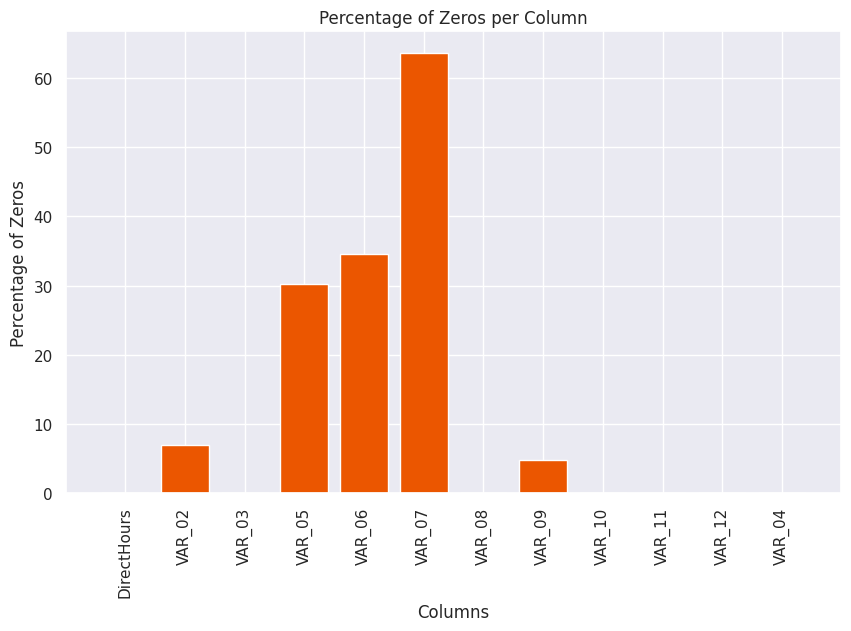

In [156]:
#create a bar plot with percentage_zero_values
plt.figure(figsize=(10, 6))
plt.bar(percentage_zero_values.index, percentage_zero_values, color='#eb5600')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Zeros')
plt.title('Percentage of Zeros per Column')

In [157]:
# Checking VAR_07 and its unique values
df_ob['VAR_07'].value_counts().head()

,count
VAR_07,
0.00,340
942576.27,1
3955866.61,1
760763.13,1
693458.48,1


**Observations**
- Variables 07 have at least 63% of their values as zeros. Zeros cannot be a model, unless they are informative. In this case, for VAR_07, they are not informative. VAR_07 is not a binary variable; the resulting zeros are a function of the ETL process, which replaced nulls with zeros.
- VAR_07 will be dropped, since it is not recommended to create synthetic data beyond 10%.
- VAR_05 and VAR_06 will be left to the model phase to assess their importance, since the number of zeros in their values is beyond 30%, which is a big number to fill out.
- VAR_02 will be filled using its mean values. This procedure does not change any statistical relationship since their percentage of missingness is below 10%.
- VAR_09 will be left as is, since the value of zero has a meaningful business reason.

In [158]:
# Calculate the mean for VAR_02 and VAR_09
median_var_02 = df_ob['VAR_02'].median()

# Replace zero values in VAR_02 and VAR_09 with their respective means
df_ob['VAR_02'] = df_ob['VAR_02'].replace(0, median_var_02)

print(f"Mean of VAR_02 used for replacement: {median_var_02:.2f}")

Mean of VAR_02 used for replacement: 0.49


In [159]:
# Checking the percentage of the count of the number of Zeros after replacement
zero_values_after_fill = (df_ob == 0).sum()
total_rows = df_ob.shape[0]
percentage_zero_values_after_fill = (zero_values_after_fill / total_rows) * 100
print("Percentage of Zeros per Column after filling:")
print(percentage_zero_values_after_fill)

Percentage of Zeros per Column after filling:
DirectHours     0.000000
VAR_02          0.000000
VAR_03          0.000000
VAR_05         30.280374
VAR_06         34.579439
VAR_07         63.551402
VAR_08          0.000000
VAR_09          4.859813
VAR_10          0.000000
VAR_11          0.000000
VAR_12          0.000000
VAR_04          0.000000
dtype: float64


In [160]:
# Display descriptive statistics for VAR_02 and VAR_09 to show the impact
display(df_ob.describe().T)

,count,mean,std,min,25%,50%,75%,max
DirectHours,535.0,2596.416505,2.026873e+03,838.000000,838.000000,1820.450000,3662.725000,8329.00
VAR_02,535.0,0.509385,2.630960e-01,0.001107,0.309001,0.491948,0.692161,1.00
VAR_03,535.0,73.990654,8.834465e+01,6.000000,6.000000,35.000000,113.000000,427.00
VAR_05,535.0,5939.624336,6.793360e+03,0.000000,0.000000,3521.600000,9586.830000,30293.65
VAR_06,535.0,5895.054374,7.489870e+03,0.000000,0.000000,3069.400000,8962.975000,34918.25
VAR_07,535.0,549354.024075,1.161106e+06,0.000000,0.000000,0.000000,591978.820000,7613204.51
VAR_08,535.0,17.934579,1.876988e+01,1.000000,1.000000,13.000000,27.500000,94.00
VAR_10,535.0,59162.505084,8.705118e+04,3949.740000,3949.740000,12152.260000,80309.080000,479240.62
VAR_11,535.0,99082.855701,1.244223e+05,246.090000,246.090000,51427.080000,156451.190000,566827.20
VAR_12,535.0,2645.752262,5.493795e+03,-0.250000,-0.250000,-0.250000,3031.740000,35381.75


### 3.4.Categories Profiling

In [161]:
df_ob['VAR_04'].value_counts().head(15)

,count
VAR_04,
Type_02,189
Type_08,68
Type_01,64
Type_04,32
Type_10,23
Type_06,21
Type_12,13
Type_03,12
Type_07,11


In [162]:
cat_group = df_ob['VAR_04'].value_counts()
len(cat_group)

43

**Observations**
- Following a best practice that each categorical level should have at least 10 records to be statistically significant, categories that have fewer than 10 records will grouped in a 'Others' bucket. VAR_04 currently has 43 categories.

In [163]:
# Getting the categories with number of records fewer than 10 in a list
list_cats_to_group = cat_group[cat_group < 10].index.tolist()

In [164]:
# If the category is within the categories to be bucked, this code bicket them
for i in list_cats_to_group:
    df_ob['VAR_04'] = df_ob['VAR_04'].replace(i, 'Others')

In [165]:
df_ob['VAR_04'].value_counts()

,count
VAR_04,
Type_02,189
Others,92
Type_08,68
Type_01,64
Type_04,32
Type_10,23
Type_06,21
Type_12,13
Type_03,12


### 3.5.Dropping Variables

In [166]:
df_ob.drop(columns=(['VAR_07','VAR_12']), inplace=True)

In [167]:
df_ob.shape

(535, 10)

**Observations**   
As observed before:
- VAR_07 will be dropped, since it is not recommended to create synthetic data beyond 10%.
- VAR_12 should not have negative numbers given its nature, 50% of this parameter as negative seems a data quality problem.

## 4.Outliers

In [168]:
# Include the name of the numerical data types in a list
num_cols = df_ob.select_dtypes(include=['int64', 'float64']).columns.tolist()

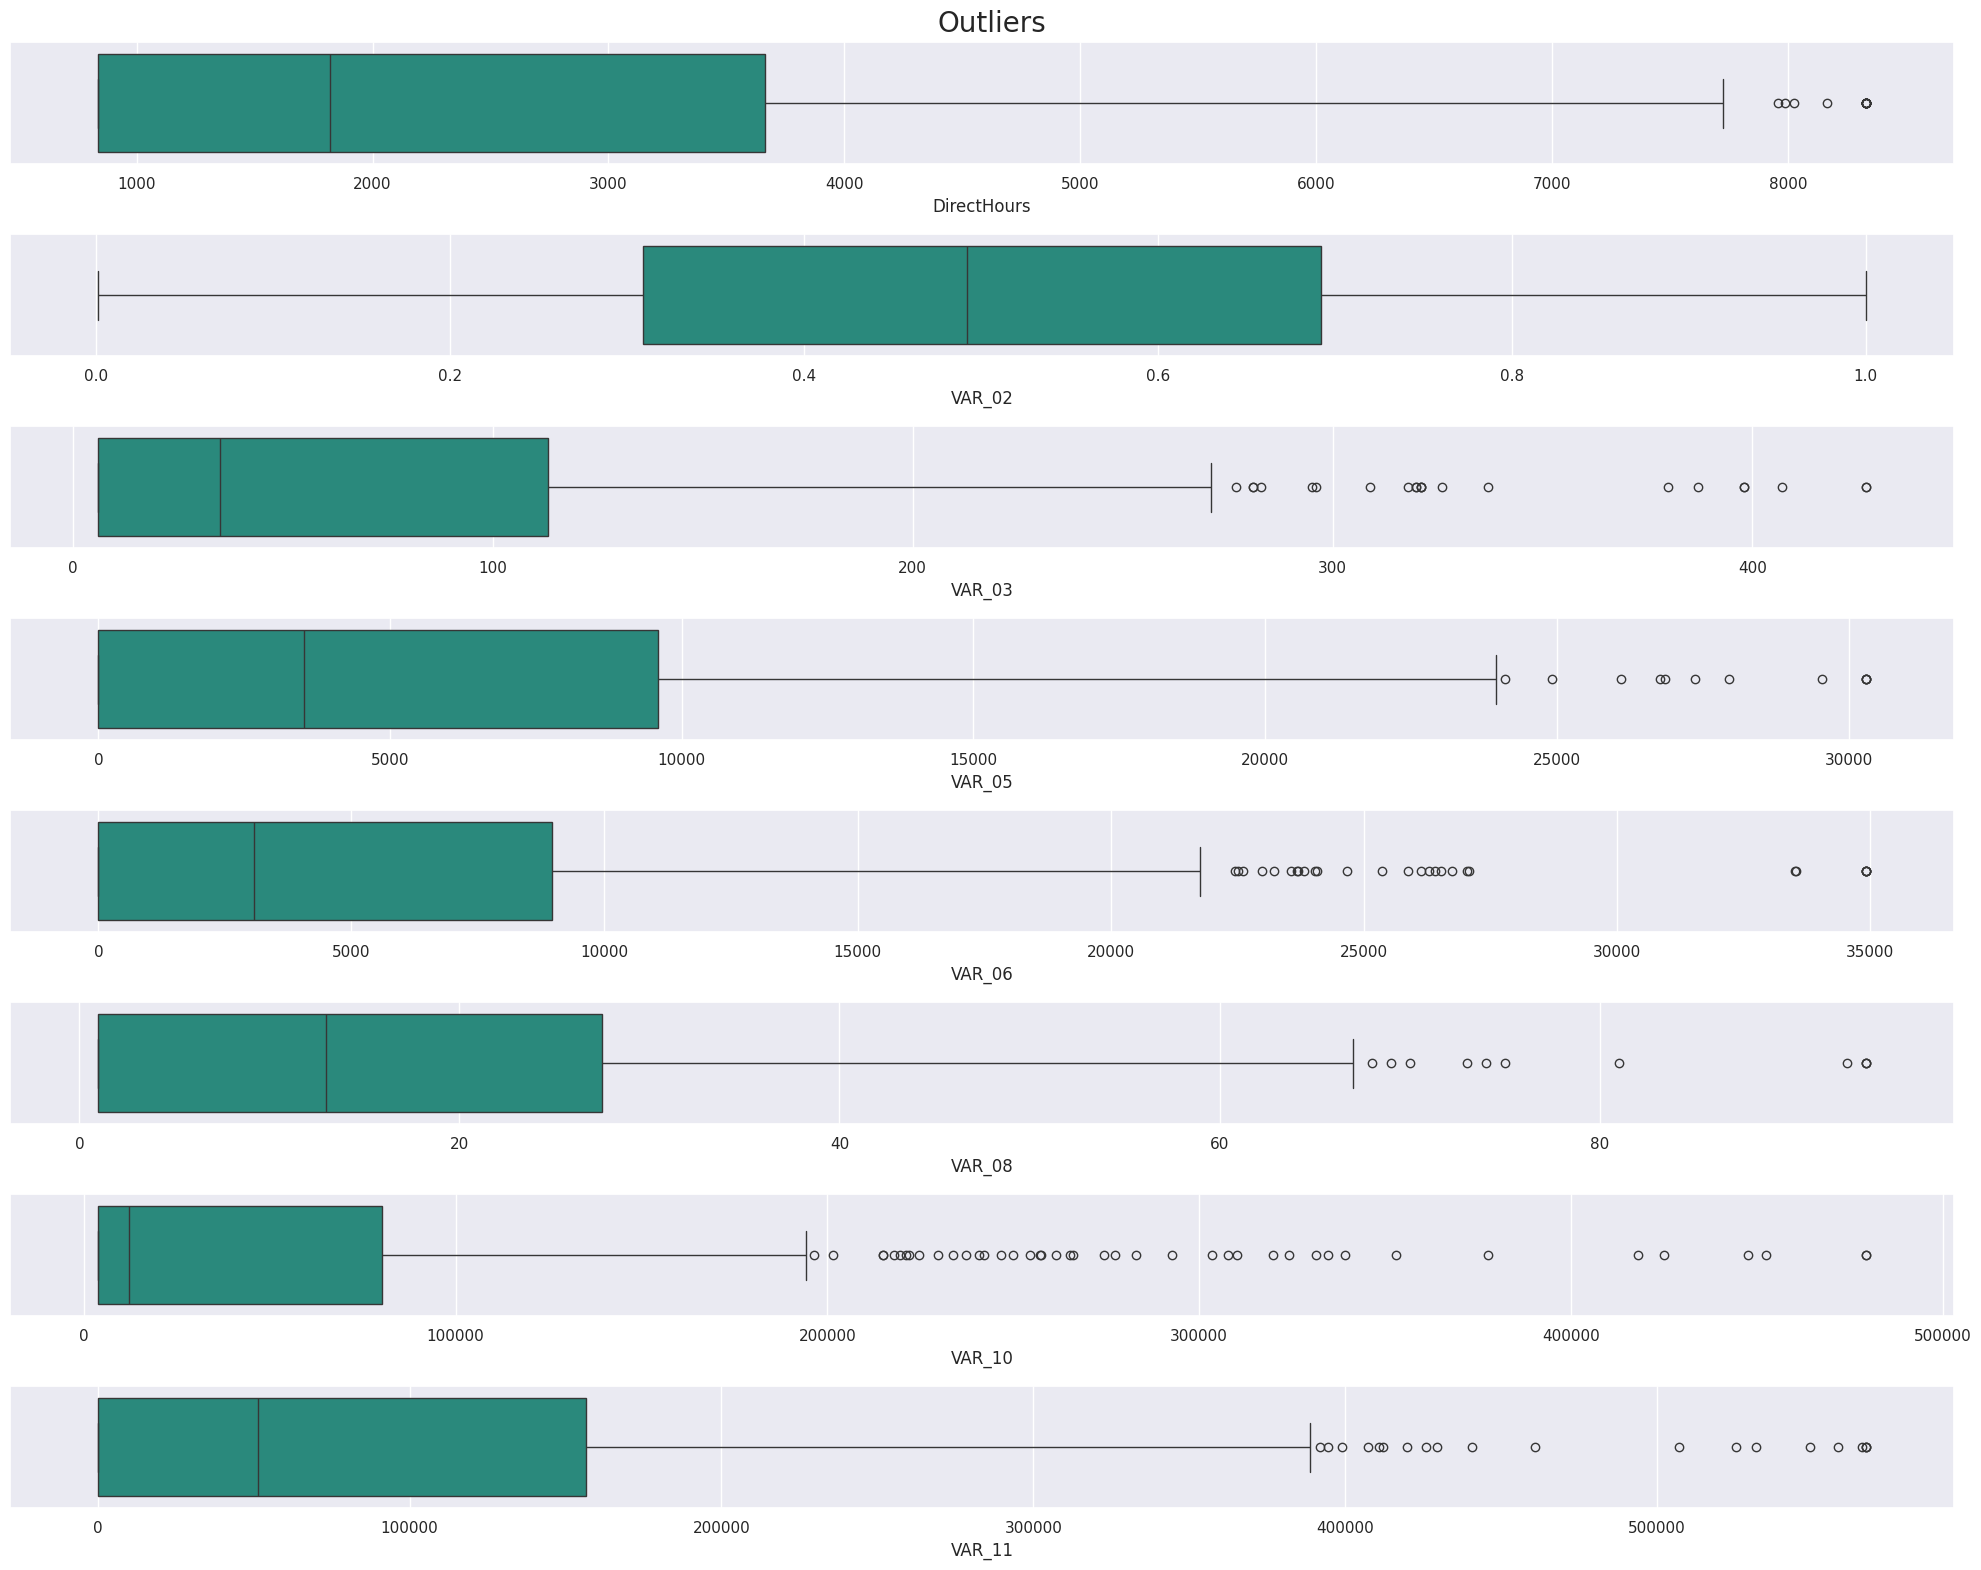

In [169]:
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(20, len(num_cols) * 2))
fig.suptitle('Outliers', fontsize=20)

for ii in range(len(num_cols)):
    sns.boxplot(x=df_ob[num_cols[ii]], ax=axes[ii], color='#1a9988')
fig.tight_layout()

**Observations**
- DirectHours: This variable is heavily right-skewed. The median is positioned low (around 1,800), with a long upper whisker and several distinct outliers reaching above 8,000.
- VAR_02: Unlike the others, this variable appears normally distributed or uniform. It shows high symmetry, the median is centered at 0.5, and there are no outliers present.
- VAR_03: Exhibits significant skewness with a median very close to zero. It contains a high density of outliers starting around 260 and extending beyond 400.
- VAR_05: Shows a wide interquartile range (IQR) but remains skewed. Outliers are frequent once the values exceed approximately 24,000.
- VAR_06: Very similar profile to VAR_05, but with a slightly higher maximum range. The outliers are clustered between 22,000 and 28,000, with two extreme values near 35,000.
- VAR_08: This variable has a relatively small scale (0–100). The median is roughly 15, and outliers begin appearing past the 65 mark.
- VAR_10: This is the most extreme case of skewness. The "box" is compressed near zero, indicating that the majority of the data occupies a tiny fraction of the total range (up to 500,000). It features a very long tail of individual outliers.
- VAR_11: Similar to VAR_10 in scale, but with a larger IQR. The data is more spread out between 0 and 150,000, with a consistent trail of outliers extending to nearly 600,000.

**Outliers Conclusion**

Because the data is heavily skewed, selecting any type of process that uses "average" (mean) to remove outliers won't work, since the extreme values have already pulled the average too far in their direction.
Tukey’s Fences technique will be used, since it caps outliers within bounds, in this case $1.5 \times IQR$ to find the boundaries of each variable.

#### 4.1.Current Data Distribution

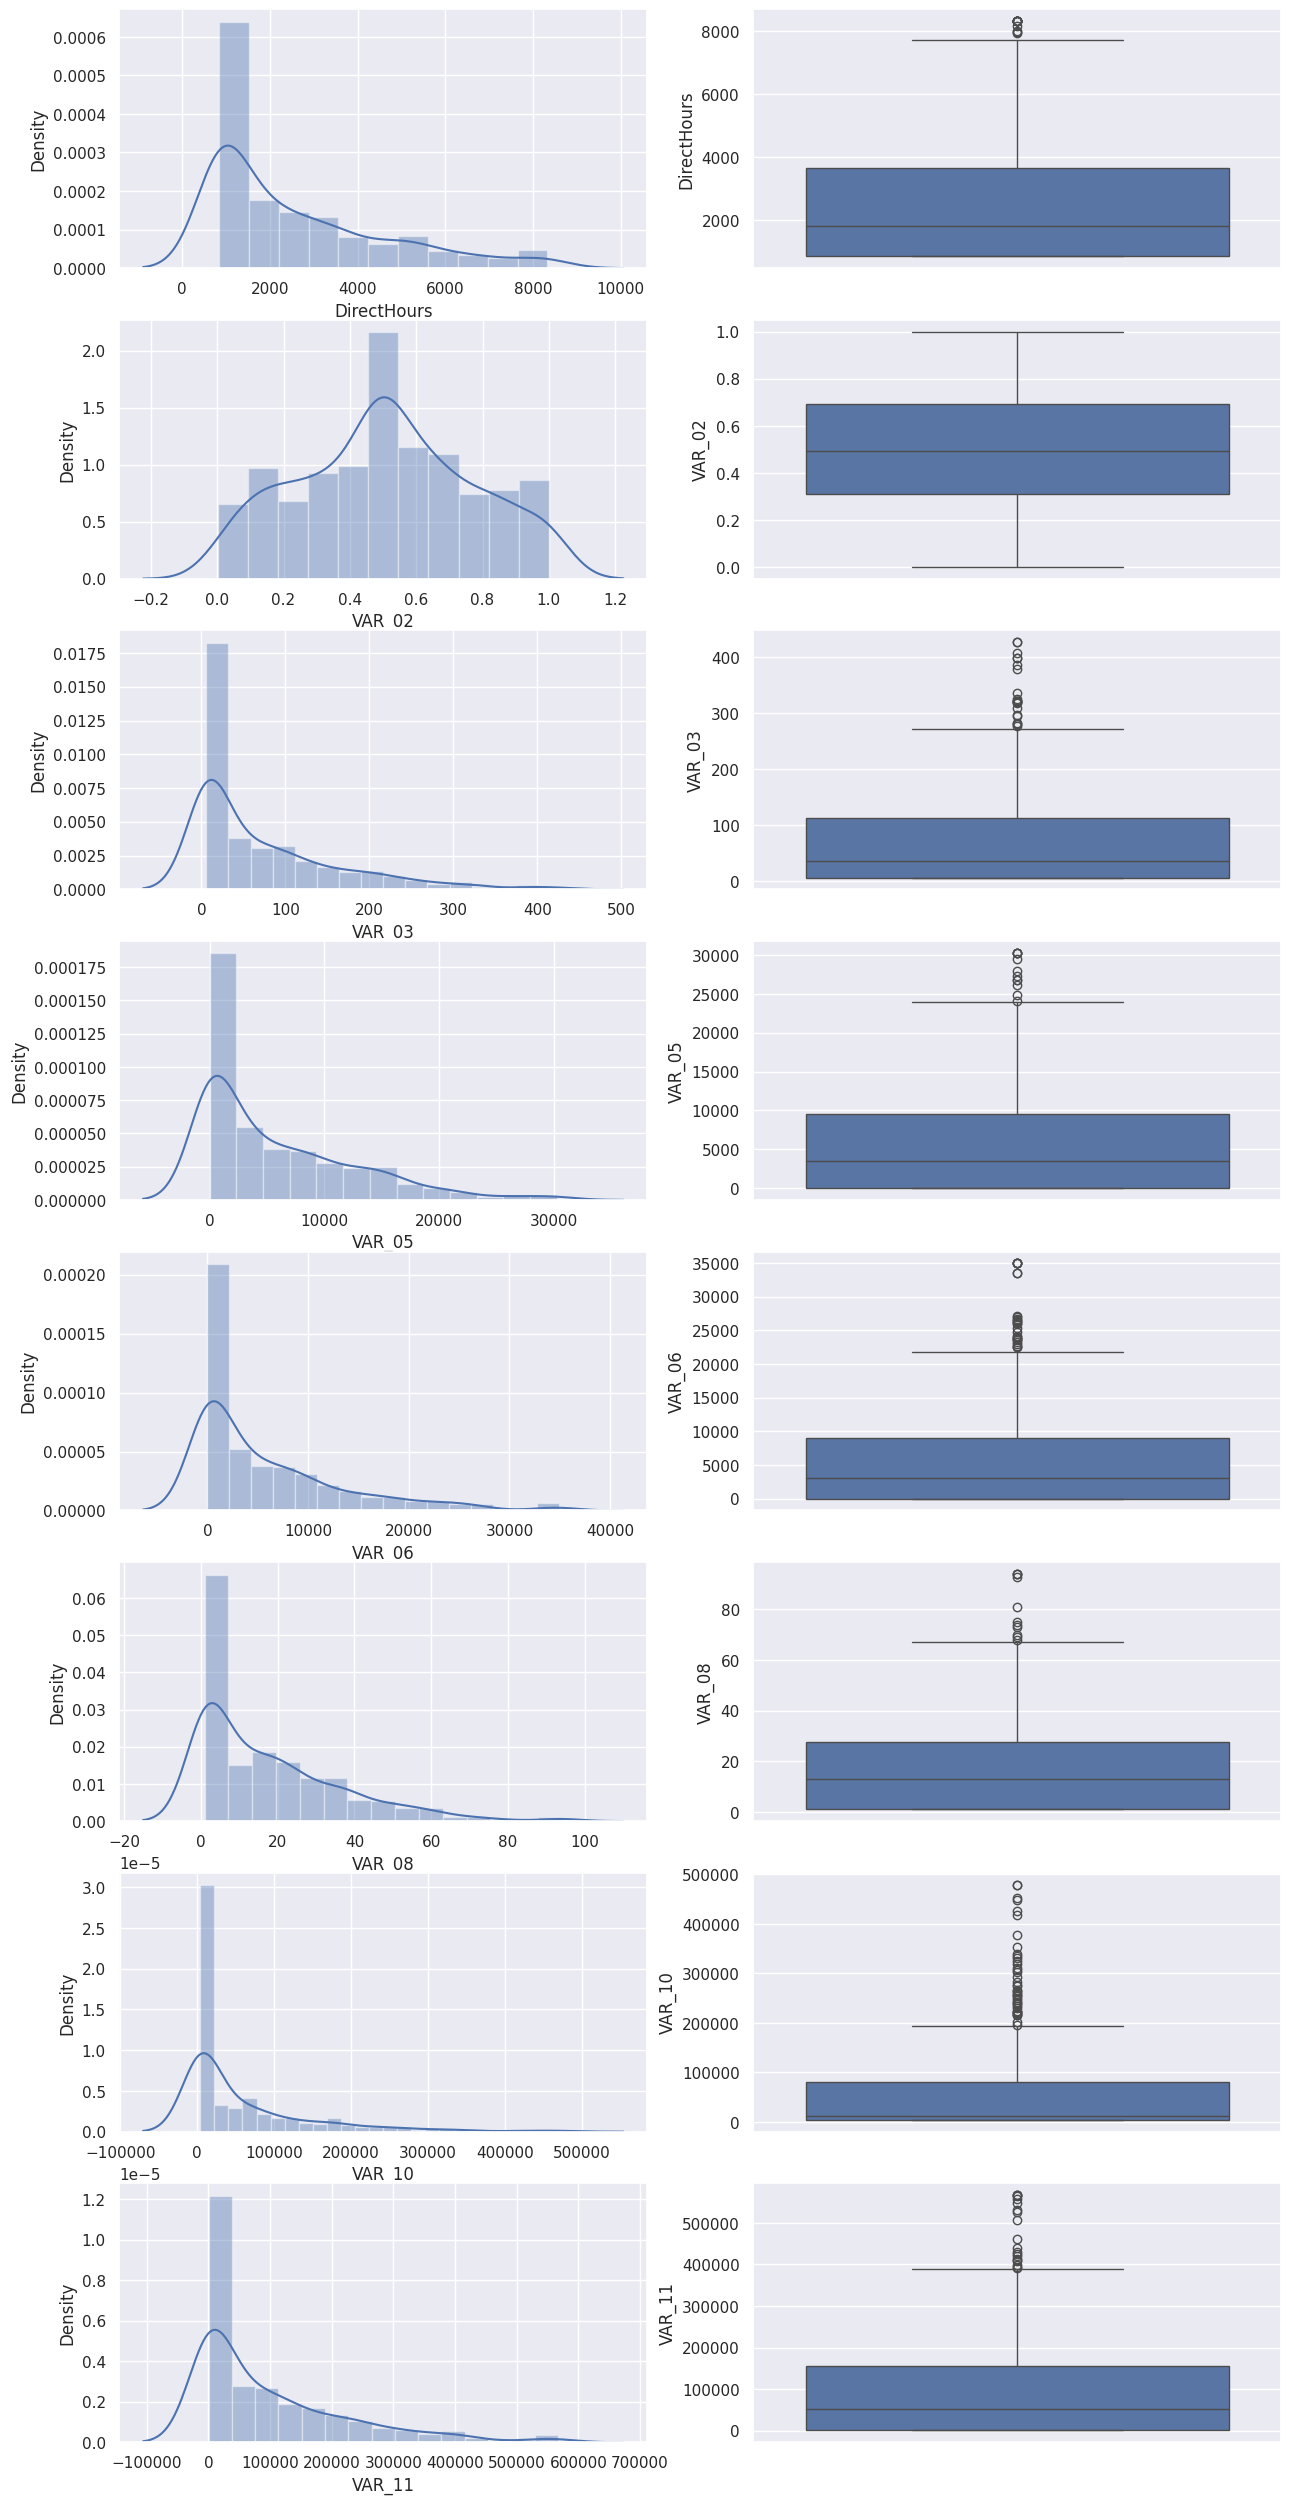

In [170]:
#Checking for Outliers
all_col = df_ob.select_dtypes(include=np.number).columns.tolist()
sns.set(font_scale=1.0)

a=1
plt.figure(figsize=(15,80))
for i in all_col:
        plt.subplot(20,2,a)
        sns.distplot(df_ob[i])
        plt.subplot(20,2,a+1)
        sns.boxplot(df_ob[i])
        a+=2


####4.2.Distrubution after outliers removal

In [171]:
def cap_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        # Snap values to the fences
        df[col] = df[col].clip(lower=lower_fence, upper=upper_fence)
    return df

Number of data points changed by cap_outliers_iqr:
  VAR_03: 22 data points
  VAR_05: 12 data points
  VAR_06: 28 data points
  VAR_08: 11 data points
  VAR_10: 42 data points
  VAR_11: 20 data points


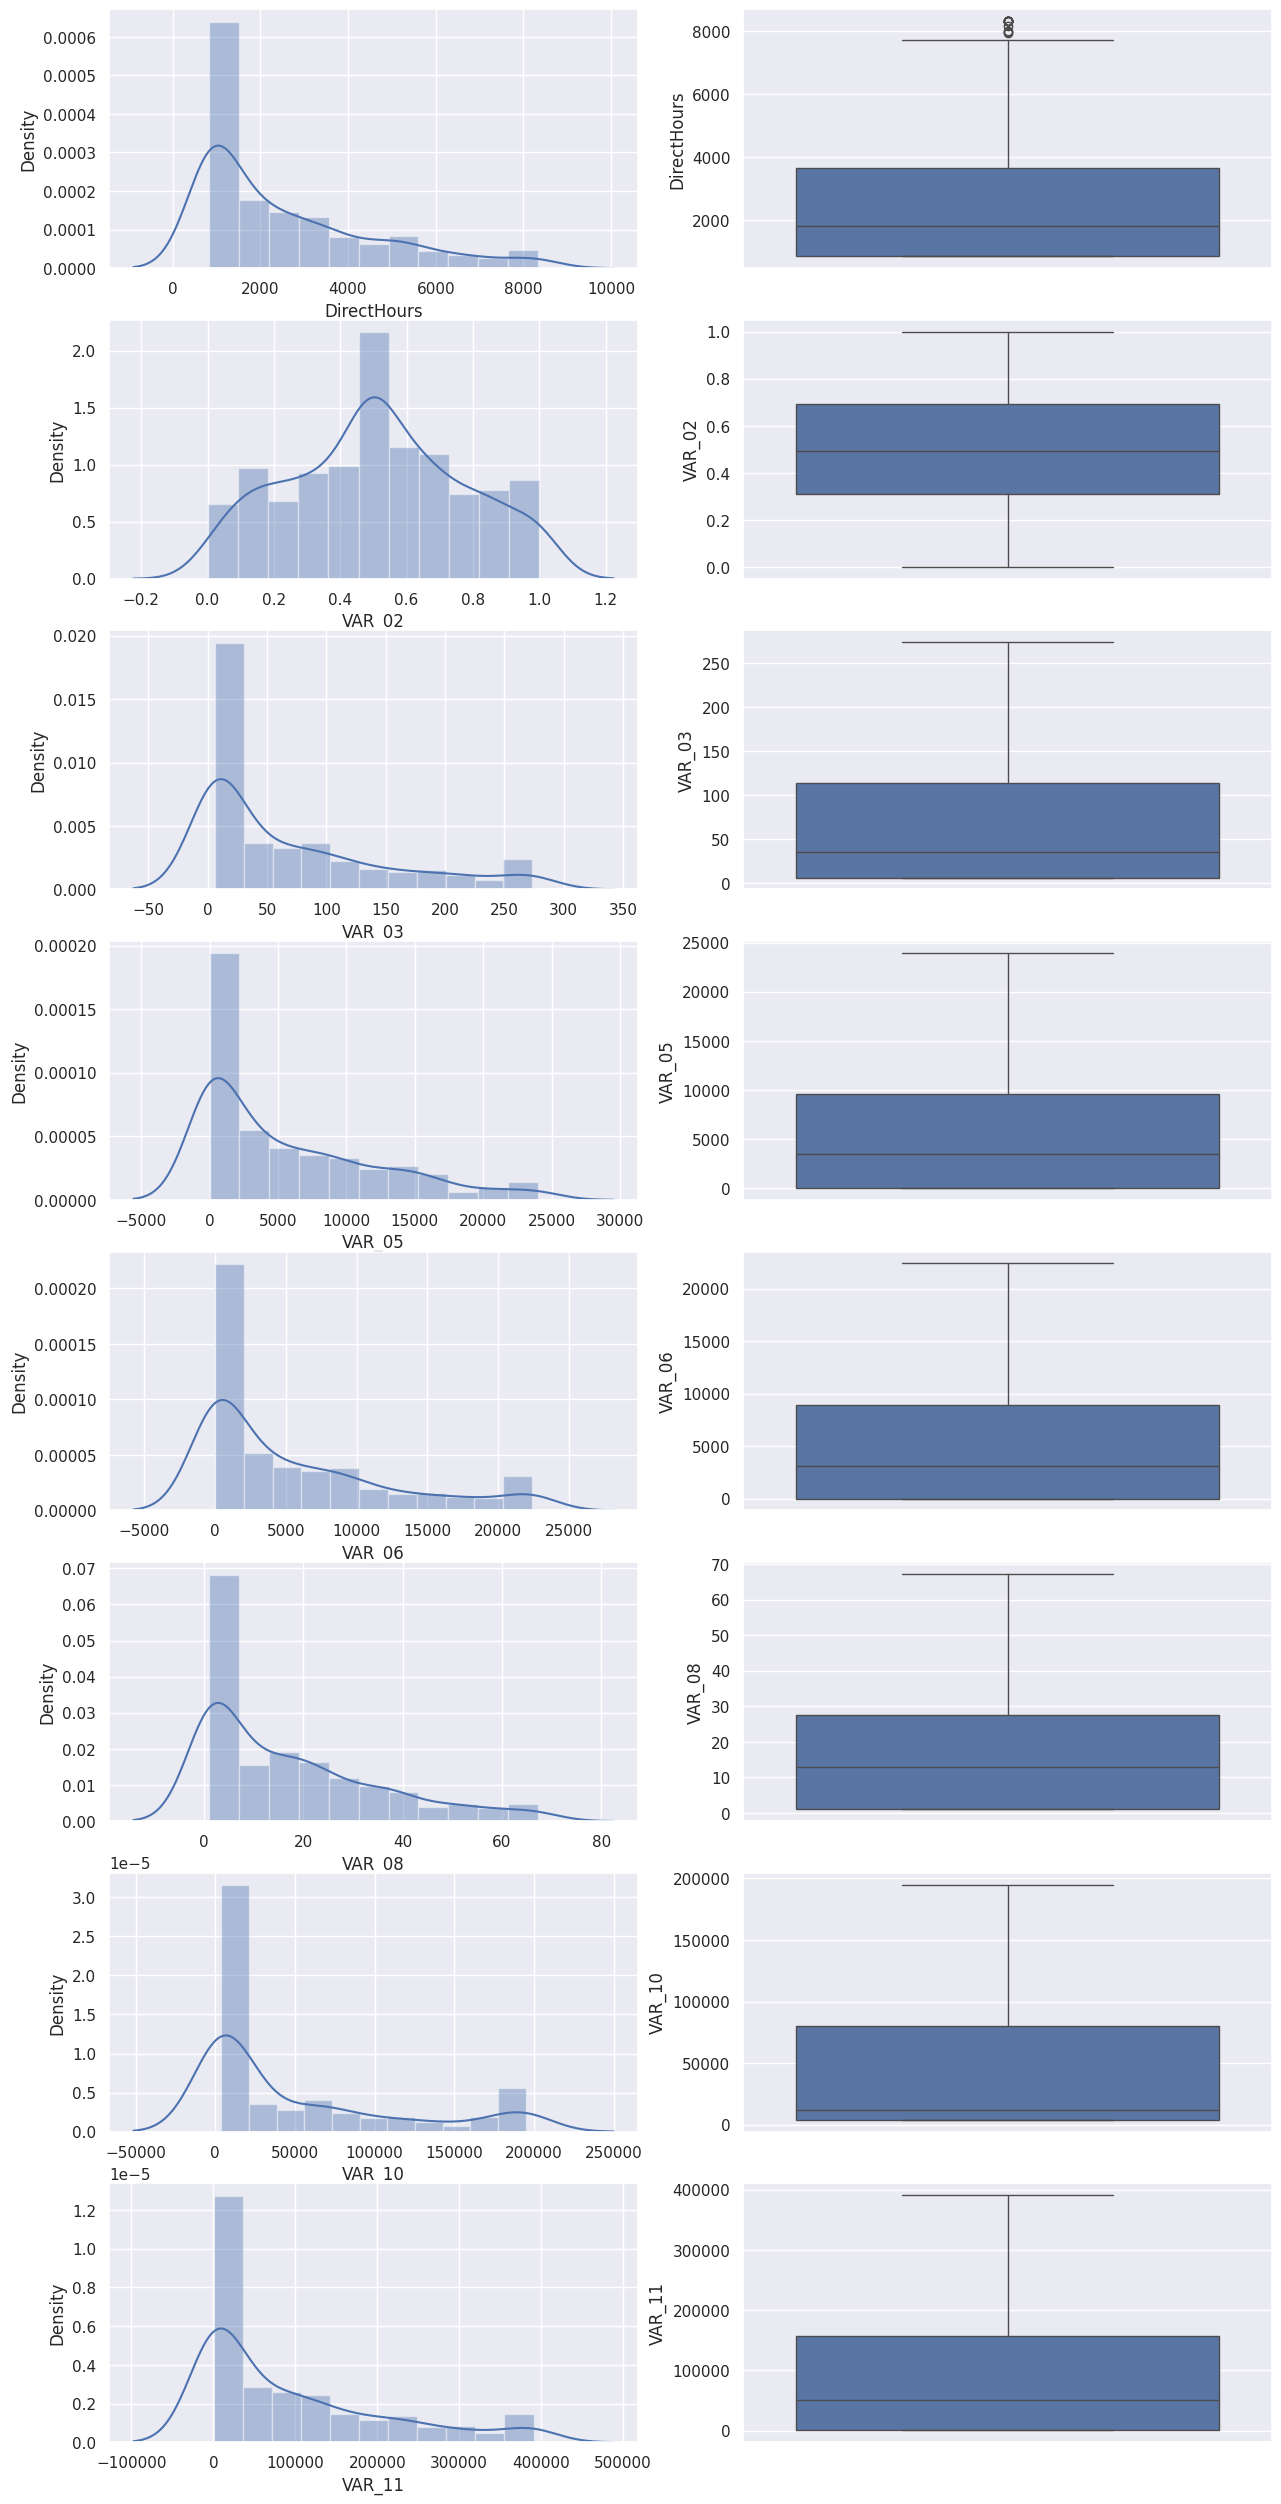

In [172]:
#Handling Outliers First
df_ob_original = df_ob.copy()

# Apply the capping function to a new DataFrame for comparison
df_ob_capped = cap_outliers_iqr(df_ob.copy(), ['VAR_03', 'VAR_05', 'VAR_06','VAR_08','VAR_10','VAR_11'])

# Columns for which outliers were capped
columns_to_check = ['VAR_03', 'VAR_05', 'VAR_06','VAR_08','VAR_10','VAR_11']

print("Number of data points changed by cap_outliers_iqr:")
for col in columns_to_check:
    changed_count = (df_ob_original[col] != df_ob_capped[col]).sum()
    print(f"  {col}: {changed_count} data points")

# Handling Outliers First
df_ob_fil = cap_outliers_iqr(df_ob, ['VAR_03', 'VAR_05', 'VAR_06','VAR_08','VAR_10','VAR_11'])

all_col = df_ob_fil.select_dtypes(include=np.number).columns.tolist()
sns.set(font_scale=1.0)

a=1
plt.figure(figsize=(15,80))
for i in all_col:
        plt.subplot(20,2,a)
        sns.distplot(df_ob_fil[i])
        plt.subplot(20,2,a+1)
        sns.boxplot(df_ob_fil[i])
        a+=2


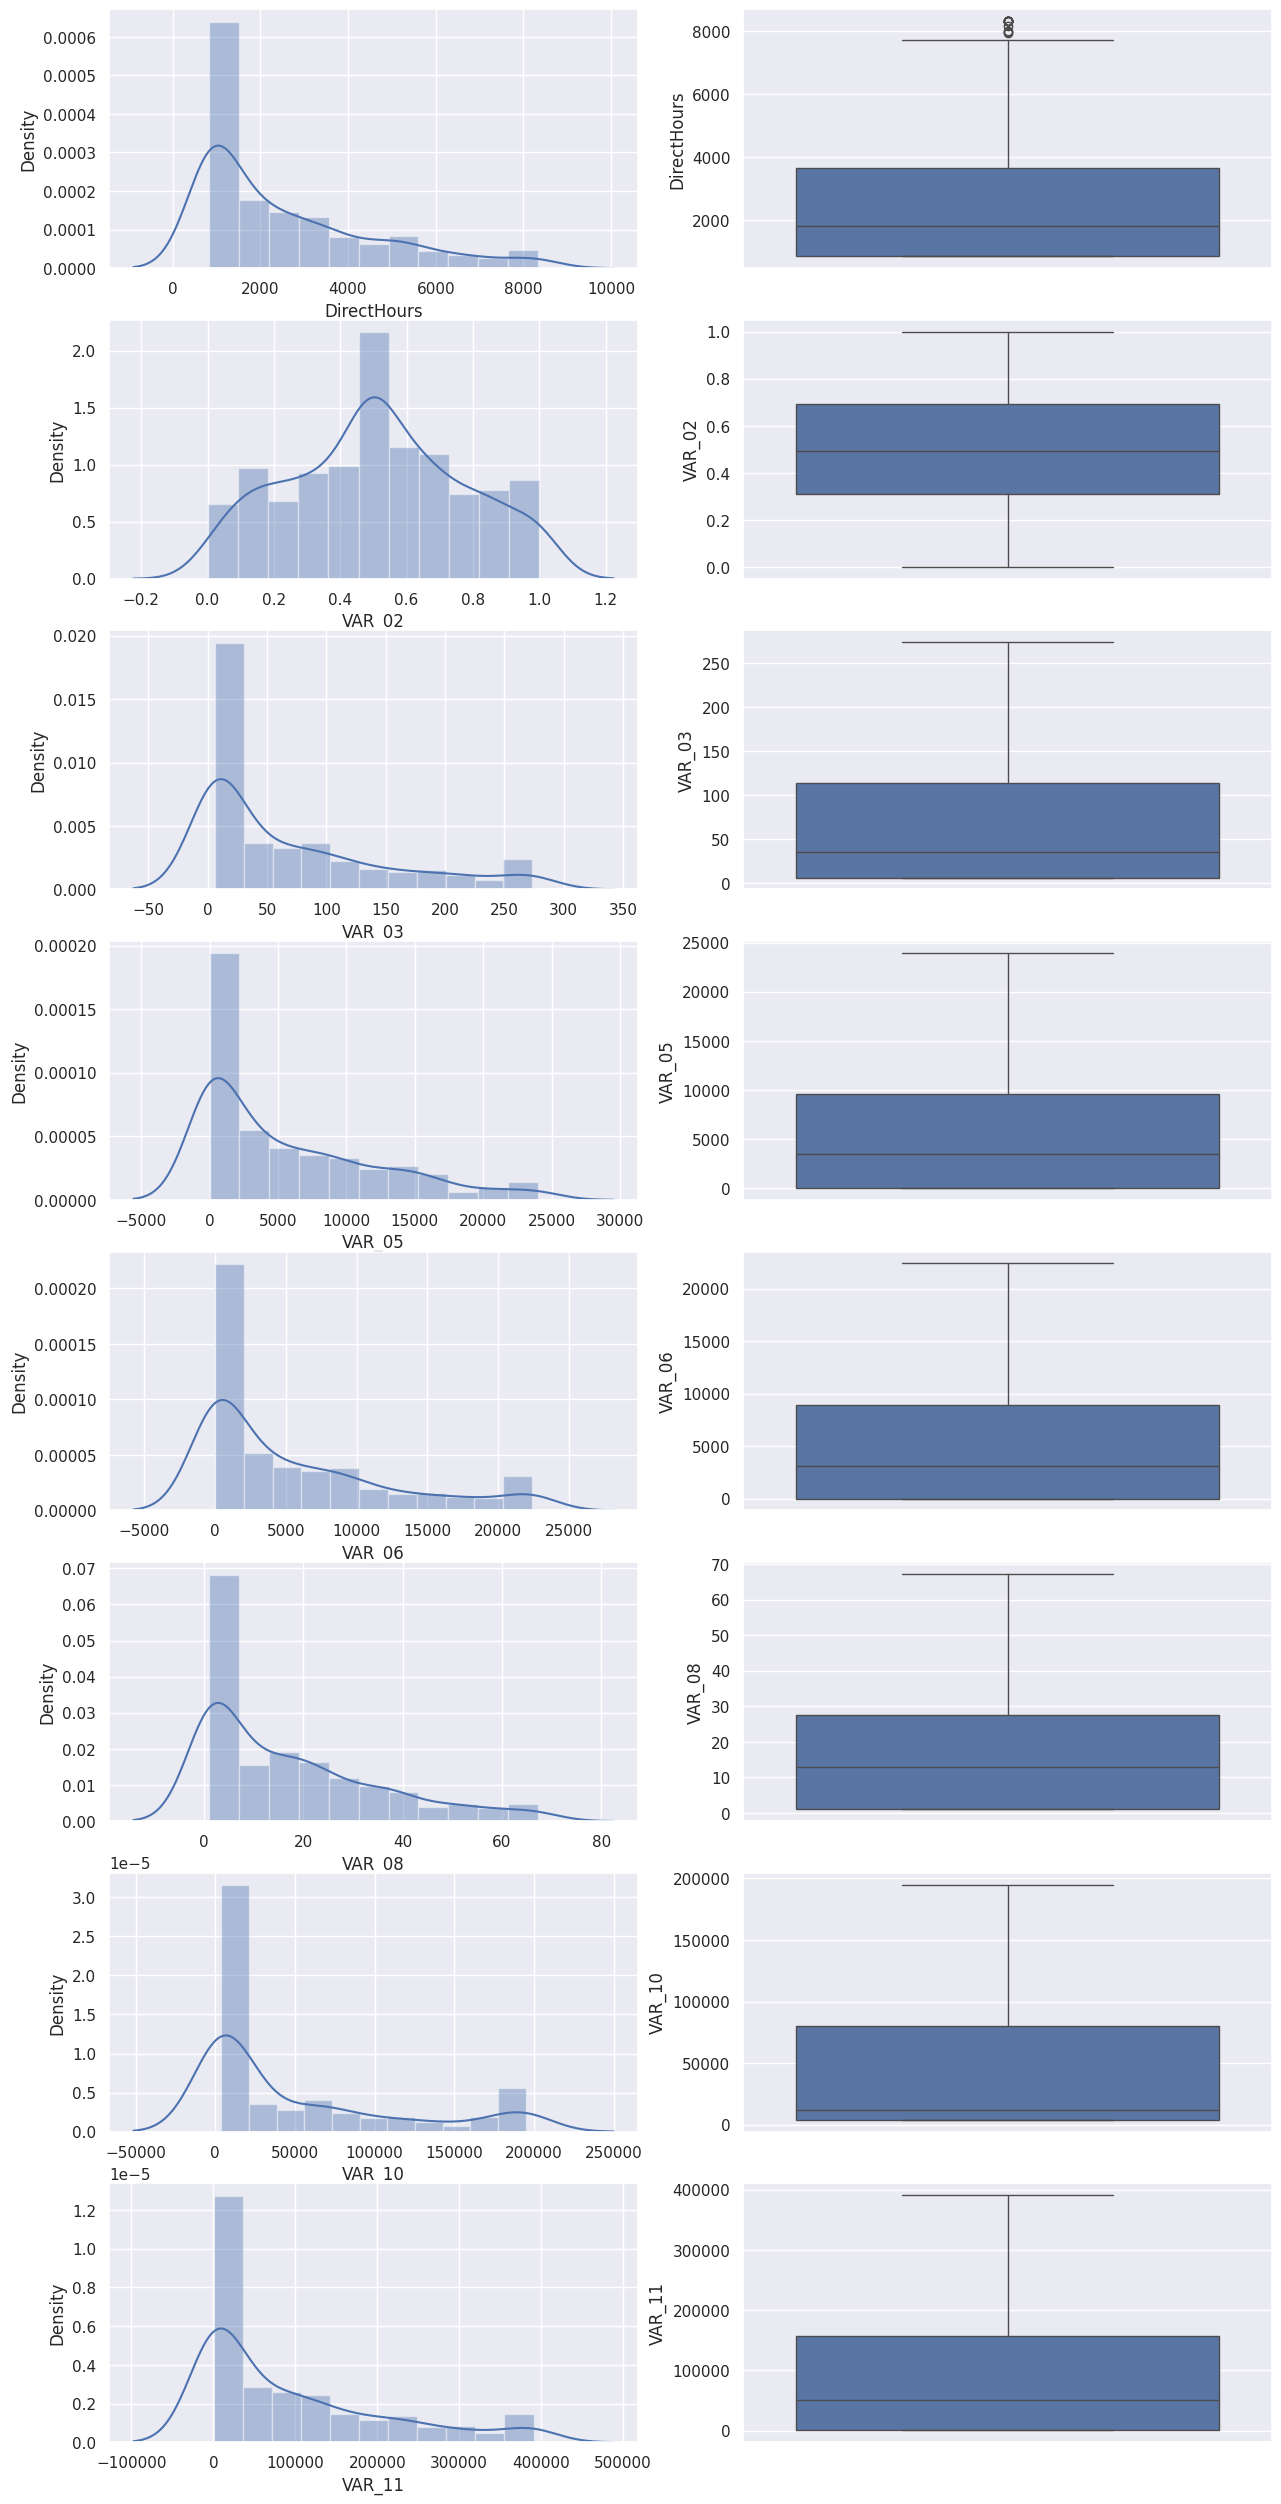

In [173]:
# Handling Outliers First
df_ob_fil = cap_outliers_iqr(df_ob, ['VAR_03', 'VAR_05', 'VAR_06','VAR_08','VAR_10','VAR_11'])

all_col = df_ob_fil.select_dtypes(include=np.number).columns.tolist()
sns.set(font_scale=1.0)

a=1
plt.figure(figsize=(15,80))
for i in all_col:
        plt.subplot(20,2,a)
        sns.distplot(df_ob_fil[i])
        plt.subplot(20,2,a+1)
        sns.boxplot(df_ob_fil[i])
        a+=2

**Observations**
- Outliers were capped in their IQR boundaries. DirectHours was not capped, since we do not want to lose any information in the target variable at this point. For DirectHours, other alternatives will be tried, for example, numerical transformations.

## 5.Transformations (Normalization)

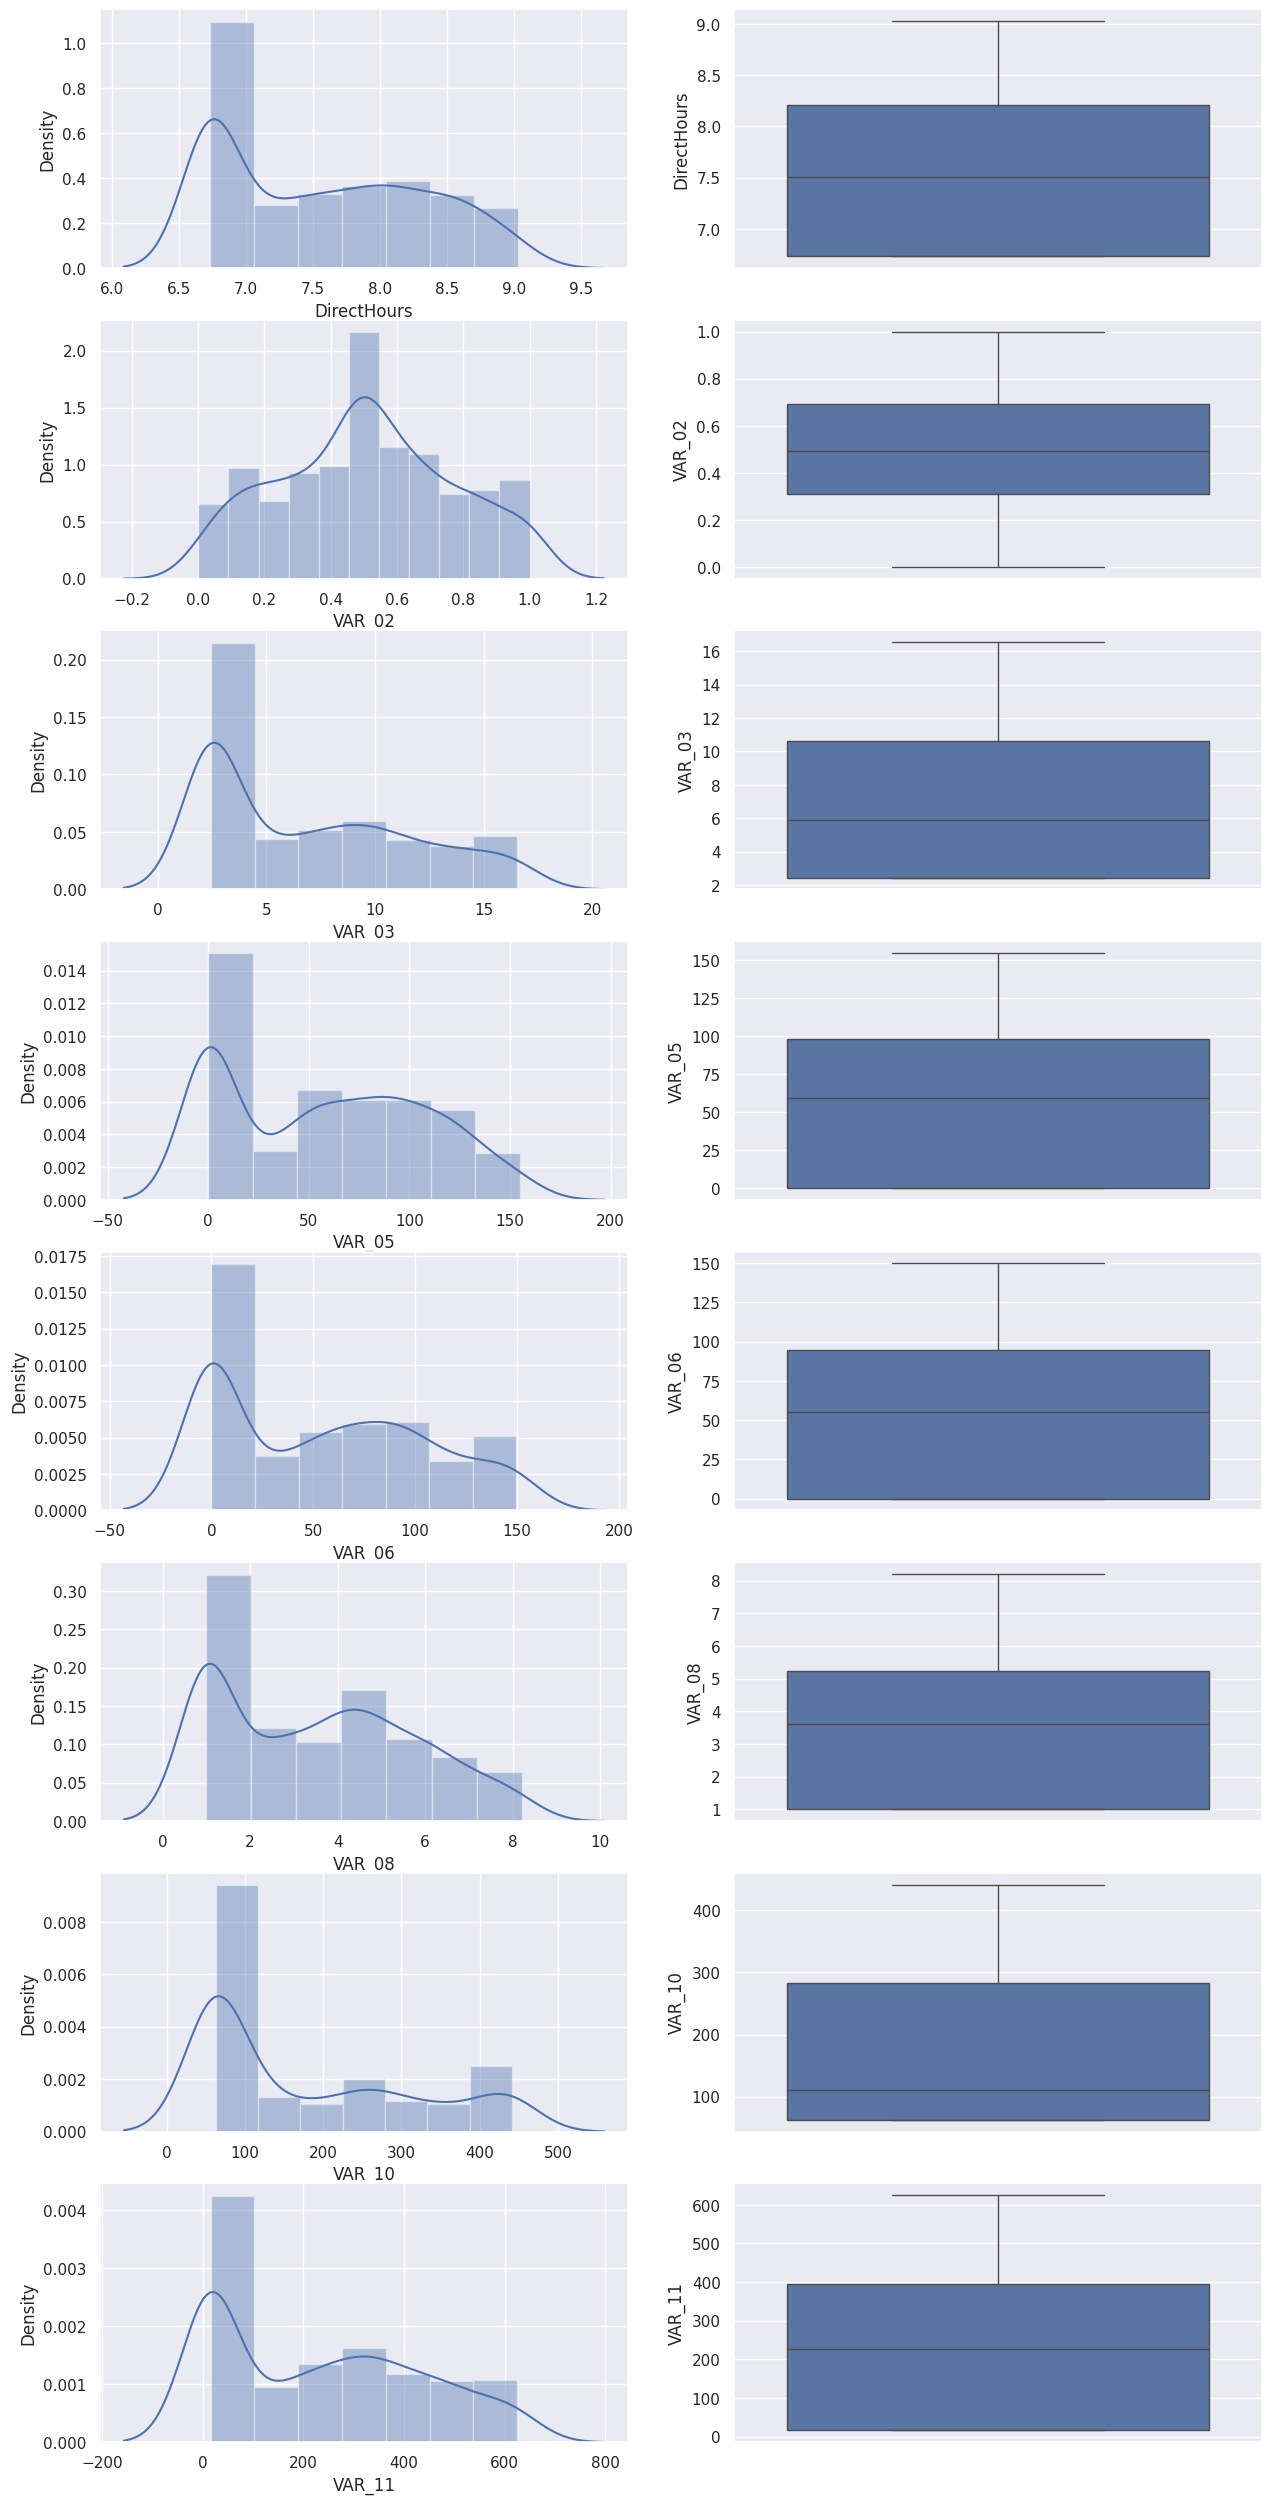

In [174]:
# Square Root Transformation

import matplotlib.pyplot as plt
import numpy as np
df_ob_fil = df_ob.copy()
columns_to_transform = ['VAR_03', 'VAR_05', 'VAR_06','VAR_08','VAR_10','VAR_11']

df_ob_fil['DirectHours']= np.log1p(df_ob_fil['DirectHours'])

for col in columns_to_transform:
    df_ob_fil[col] = np.sqrt(df_ob_fil[col])

all_col = df_ob_fil.select_dtypes(include=np.number).columns.tolist()
sns.set(font_scale=1.0)

a=1
plt.figure(figsize=(15,80))
for i in all_col:
        plt.subplot(20,2,a)
        sns.distplot(df_ob_fil[i])
        plt.subplot(20,2,a+1)
        sns.boxplot(df_ob_fil[i])
        a+=2


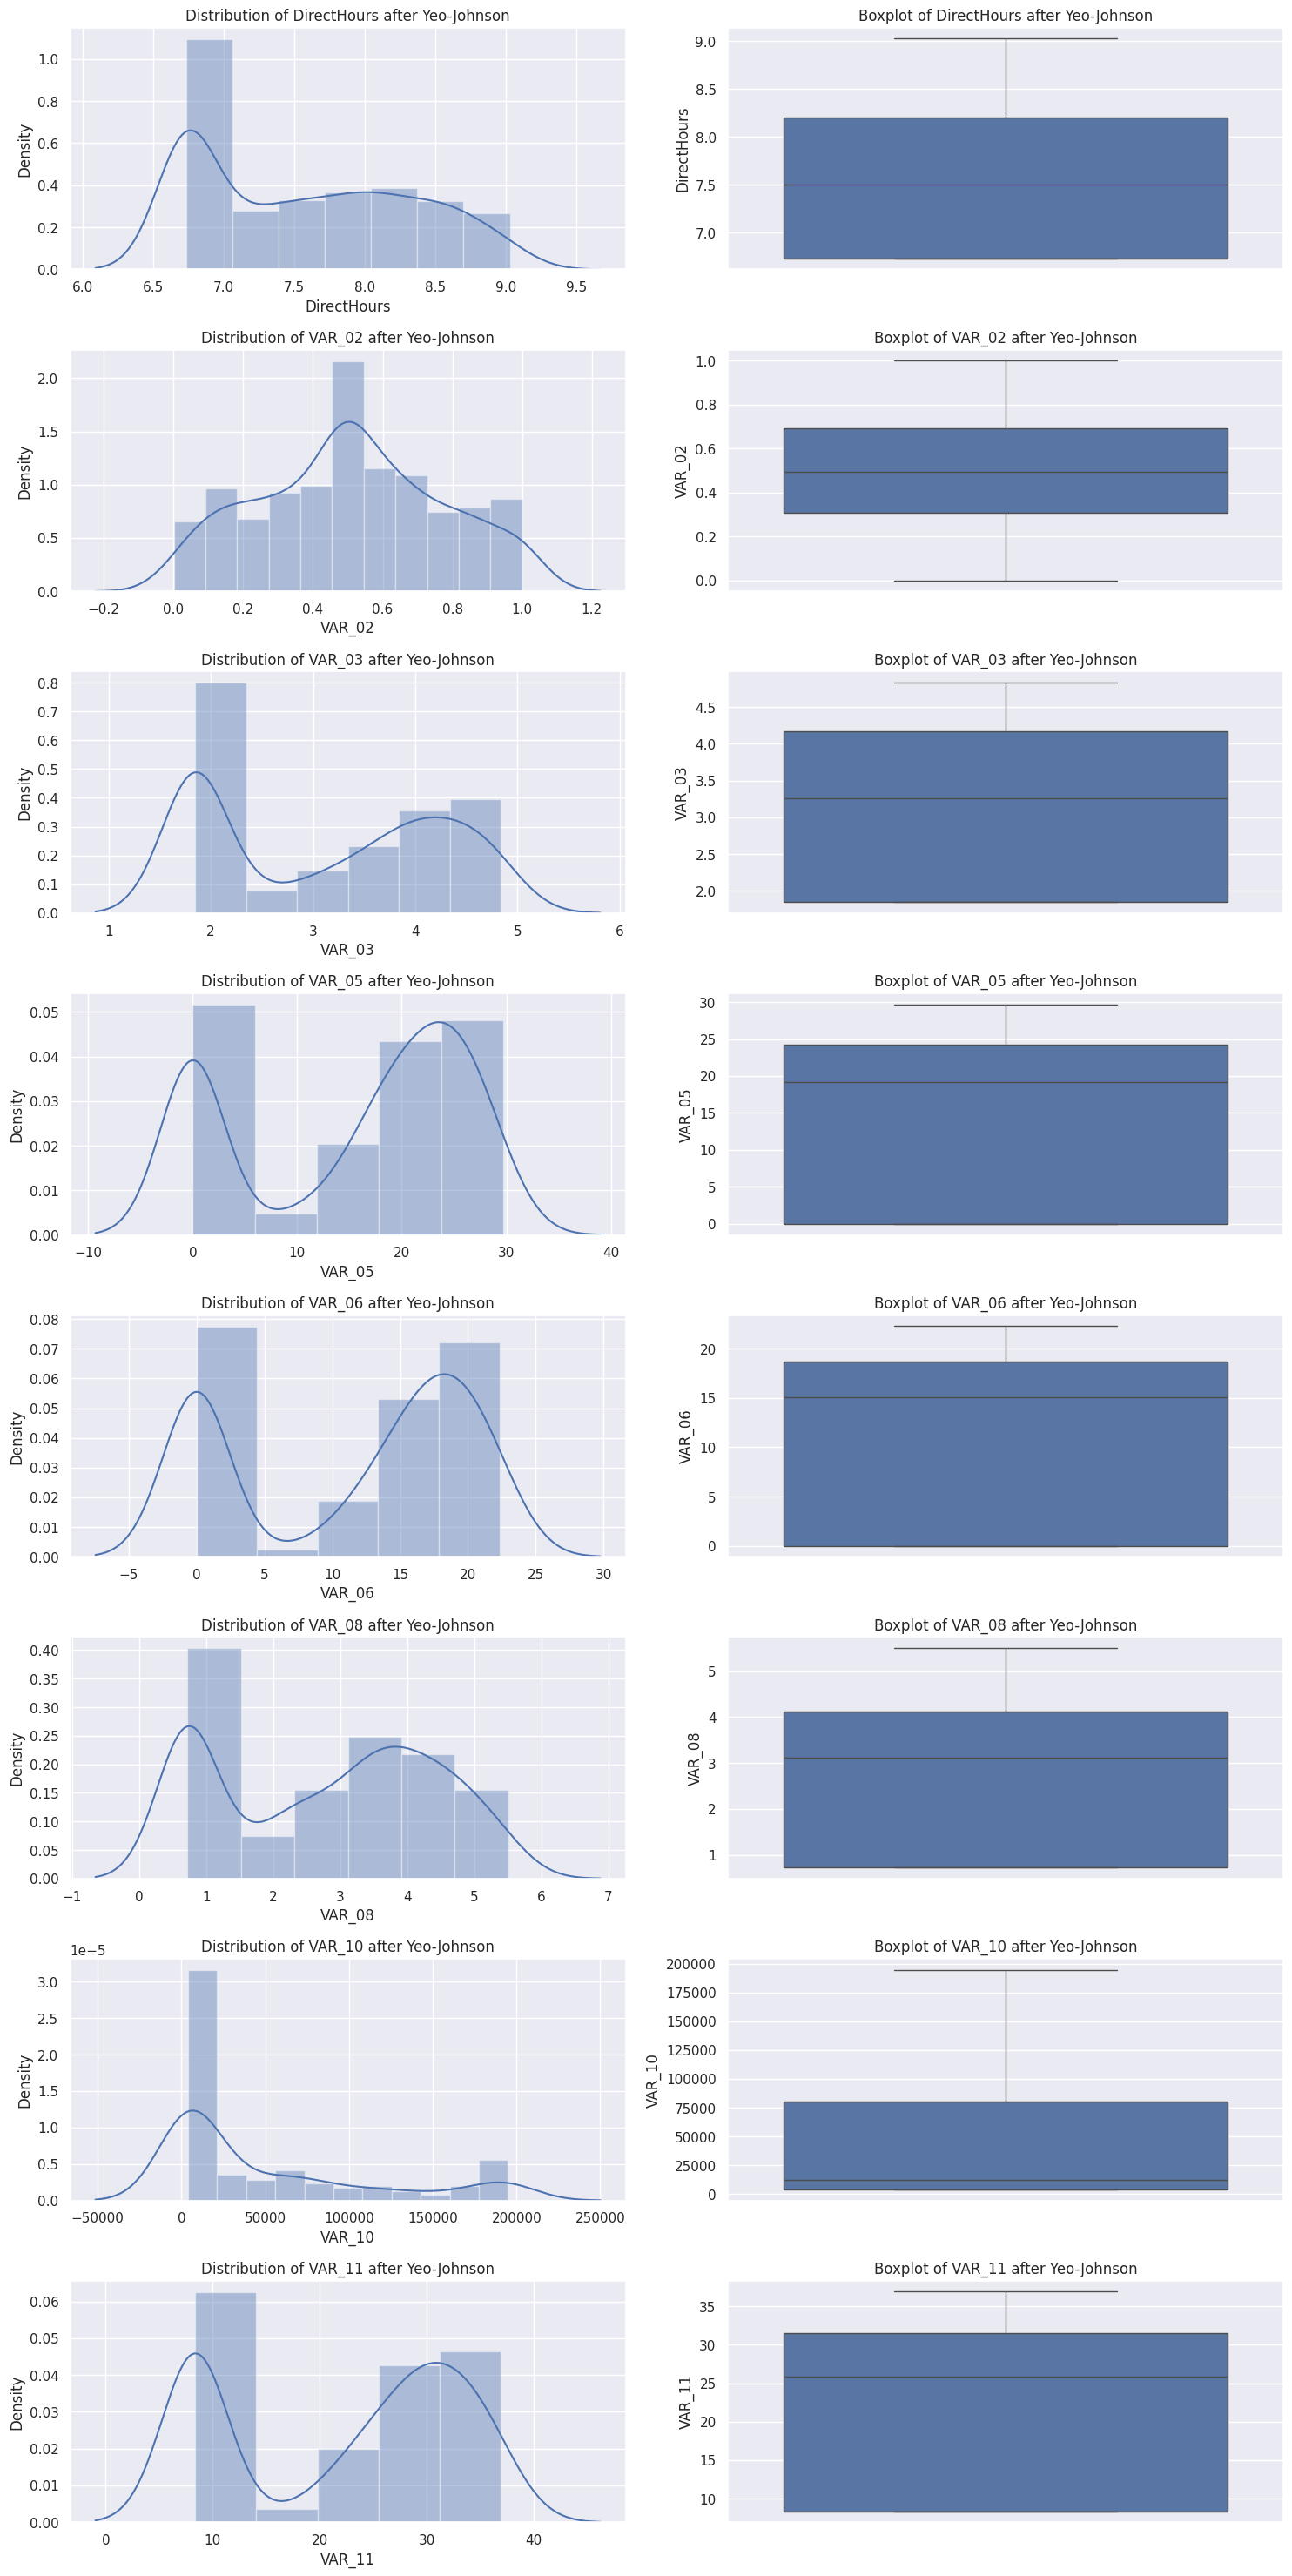

In [175]:
# Yeo-Johnson Transformation
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import numpy as np

df_ob_yj = df_ob.copy()

# Columns to apply Yeo-Johnson transformation
columns_to_transform_yj = ['VAR_03', 'VAR_05', 'VAR_06', 'VAR_08','VAR_11']

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson', standardize=False)

for col in columns_to_transform_yj:
    # Reshape the data for the transformer
    data_reshaped = df_ob_yj[col].values.reshape(-1, 1)
    df_ob_yj[col] = pt.fit_transform(data_reshaped)

# Apply log transformation to 'DirectHours' as it's the target variable
df_ob_yj['DirectHours'] = np.log1p(df_ob_yj['DirectHours'])

all_col = df_ob_yj.select_dtypes(include=np.number).columns.tolist()
sns.set(font_scale=1.0)

a = 1
plt.figure(figsize=(15, 80))
for i in all_col:
    plt.subplot(20, 2, a)
    sns.distplot(df_ob_yj[i])
    plt.title(f"Distribution of {i} after Yeo-Johnson")
    plt.subplot(20, 2, a + 1)
    sns.boxplot(df_ob_yj[i])
    plt.title(f"Boxplot of {i} after Yeo-Johnson")
    a += 2

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

**Observations**     
Three different attempts to normalize the data, in other words, get a Normal (or Gaussian) Distribution, were tried:
- Square Root Transformation
- Yeo-Johnson Transformation
- Log Transformation

**None of them succeeded**; in fact, Yeo-Johnson and the Square Root transformation resulted in a bi-modal distribution as observed in most of the charts above.

- Log transform DirectHours resulted in a better distribution, but far from a normal Gaussian.



**Conclusion**
- The assumption of having a normal distribution for all predictors cannot be achieved. Likely, the data distribution does not meet the assumption of normality.
- DirectHours transformed logarithmically will be maintained.

#### 5.1.Feature Engineering for experimentation

In [176]:
# Value used 3662.725 represents the 3rd Quantile of DirectHours
# get the third quantile of DirectHours
third_quantile = df_ob['DirectHours'].quantile(0.75)
third_quantile
df_ob['SizeFlag'] = np.where(df_ob['DirectHours'] > third_quantile, 'Large', 'Small')

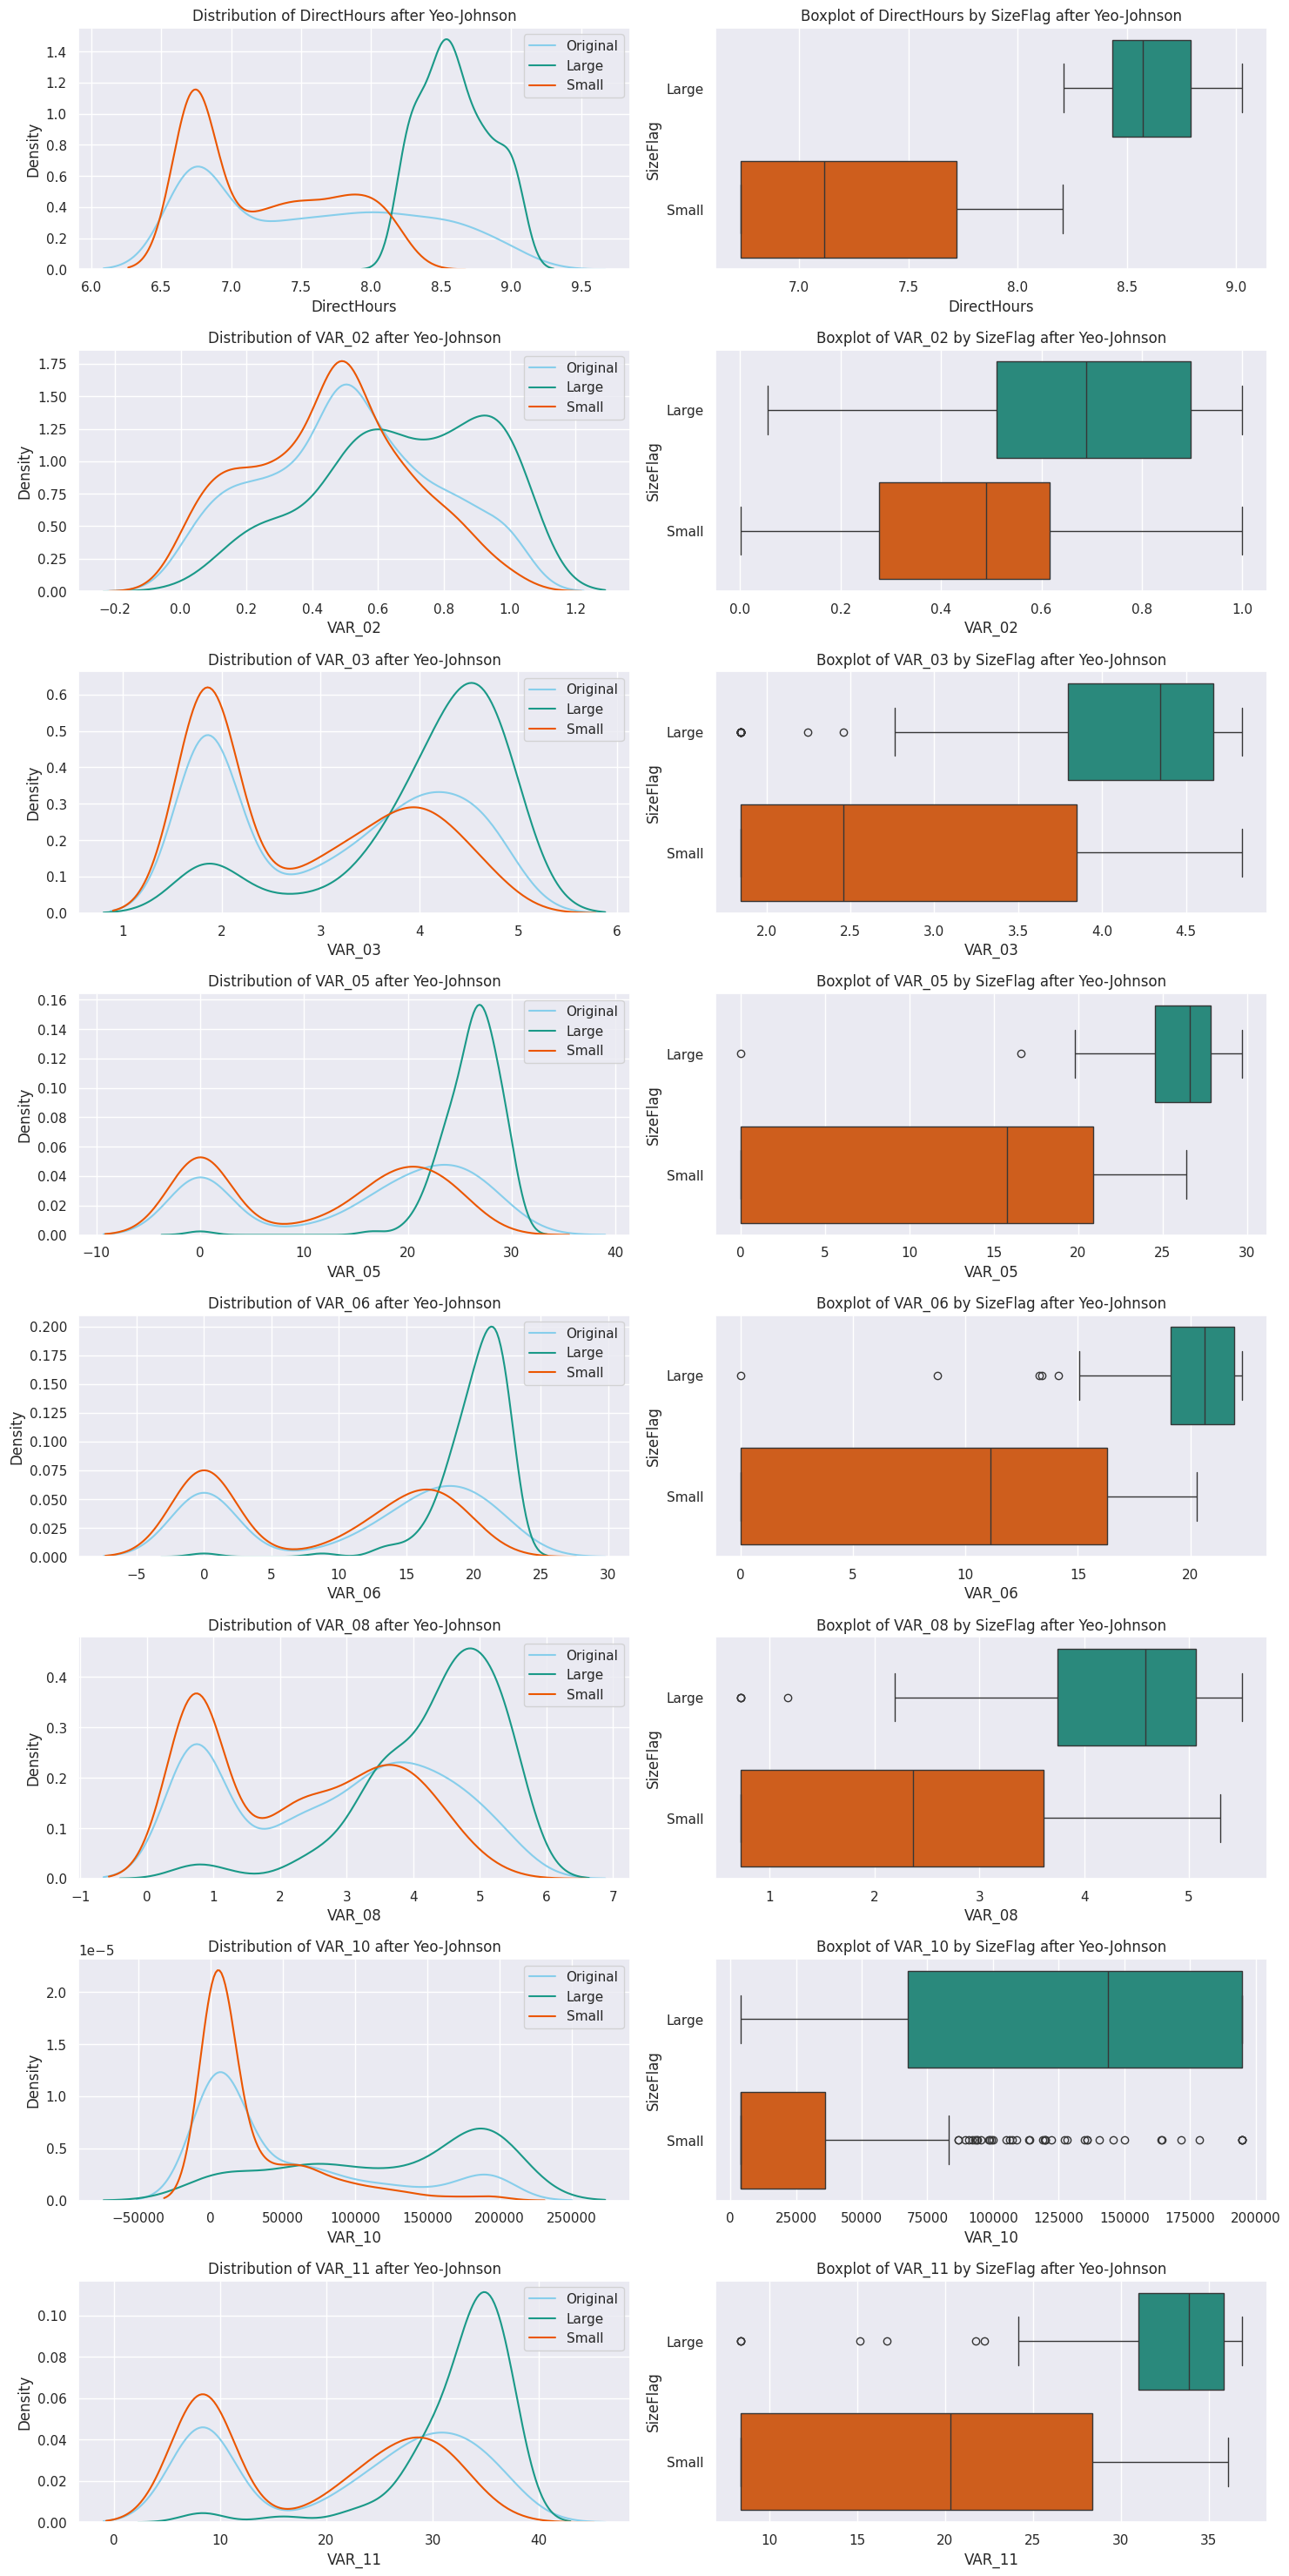

In [177]:
# Yeo-Johnson Transformation
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_ob_yj = df_ob.copy()

# Columns to apply Yeo-Johnson transformation
columns_to_transform_yj = ['VAR_03', 'VAR_05', 'VAR_06', 'VAR_08', 'VAR_11']

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson', standardize=False)

for col in columns_to_transform_yj:
    # Reshape the data for the transformer
    data_reshaped = df_ob_yj[col].values.reshape(-1, 1)
    df_ob_yj[col] = pt.fit_transform(data_reshaped)

# Apply log transformation to 'DirectHours' as it's the target variable
df_ob_yj['DirectHours'] = np.log1p(df_ob_yj['DirectHours'])

all_col = df_ob_yj.select_dtypes(include=np.number).columns.tolist()
sns.set(font_scale=1.0)

a = 1
plt.figure(figsize=(15, 80))
for i in all_col:
    plt.subplot(20, 2, a)
    # Use hue for SizeFlag in distplot
    sns.distplot(df_ob_yj[i], hist=False, color='skyblue', label='Original')
    sns.distplot(df_ob_yj[df_ob_yj['SizeFlag'] == 'Large'][i], hist=False, color='#1a9988', label='Large')
    sns.distplot(df_ob_yj[df_ob_yj['SizeFlag'] == 'Small'][i], hist=False, color='#eb5600', label='Small')
    plt.title(f"Distribution of {i} after Yeo-Johnson")
    plt.legend()

    plt.subplot(20, 2, a + 1)
    # Use hue for SizeFlag in boxplot
    sns.boxplot(x=df_ob_yj[i], y=df_ob_yj['SizeFlag'], palette={'Large': '#1a9988', 'Small': '#eb5600'})
    plt.title(f"Boxplot of {i} by SizeFlag after Yeo-Johnson")
    a += 2

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()


In [178]:
# Apply log transformation to 'DirectHours'
df_ob['DirectHours'] = np.log1p(df_ob['DirectHours'])

**Observations**        
To identify the reasons behind the bi-normal distribution, a categorical variable was created to separate small from large jobs.


**Conclusions**    
The size of the job, in terms of DirectHours, has a significant influence on the distributions of all parameters, which could drive a separate model for each group: Small or Large. It can also drive the need for non-linear models that do not rely on distribution assumptions, for example, normality. This is the case for tree-based models. At this point, no transformations will be executed, since they do not help. Instead, this exercise opens up space for different experimentation paths at the modeling phase.

##6.Encoding

The dataset has only one categorical variable, VAR_04, and since machine learning models do not process text, an encoding step is necessary to convert text to numerical values.
I will use one-hot encoding for this process, since the categoricals in VAR_04 do not have an order or any order that should be maintained, otherwise I would use label encoding (e.g. 1,2,3) where the model would capture the ordinal sequence and interpret that 3 is greater than 1.    
One-hot encoding will convert each category into binary columns (0s and 1s) indicating whether that category exists for a given record (row).

In [179]:
df_ob.dtypes

,0
DirectHours,float64
VAR_02,float64
VAR_03,float64
VAR_05,float64
VAR_06,float64
VAR_08,float64
VAR_09,object
VAR_10,float64
VAR_11,float64
VAR_04,category


In [180]:
print(df_ob['VAR_04'].unique().tolist())
print(len(df_ob['VAR_04'].unique()))

['Type_01', 'Type_02', 'Type_03', 'Type_04', 'Others', 'Type_06', 'Type_07', 'Type_08', 'Type_10', 'Type_12', 'Type_17']
11


In [181]:
# Preparing a variable for imbalance treatment later
import pandas as pd
df_ob['VAR_04_Bins'] = df_ob['VAR_04'].str.replace('Type_', '', regex=False)
df_ob['VAR_04_Bins'] = df_ob['VAR_04_Bins'].replace('Others', '99')
df_ob['VAR_04_Bins'] = pd.to_numeric(df_ob['VAR_04_Bins'])

In [182]:
# apply one-hot encoding on VAR_04
df_ob_final = pd.get_dummies(df_ob, columns=['VAR_04'], drop_first=True)
df_ob_final.head()

,DirectHours,VAR_02,VAR_03,VAR_05,VAR_06,VAR_08,VAR_09,VAR_10,VAR_11,SizeFlag,VAR_04_Bins,VAR_04_Type_02,VAR_04_Type_03,VAR_04_Type_04,VAR_04_Type_06,VAR_04_Type_07,VAR_04_Type_08,VAR_04_Type_10,VAR_04_Type_12,VAR_04_Type_17,VAR_04_Others
0,8.636190,0.659678,120.0,16667.86,17326.77,38.0,19288.800000000,141029.92,310179.67,Large,1,False,False,False,False,False,False,False,False,False,False
1,6.924711,0.382512,6.0,2746.99,772.03,5.0,5079.680000000,3949.74,52035.49,Small,1,False,False,False,False,False,False,False,False,False,False
2,8.218968,0.387494,125.0,16030.64,8711.95,31.0,4130.540000000,122317.72,180962.70,Large,2,True,False,False,False,False,False,False,False,False,False
3,7.483059,0.286059,72.0,6892.49,3021.78,13.0,51.000000000,27087.28,61689.56,Small,2,True,False,False,False,False,False,False,False,False,False
4,6.732211,0.491948,6.0,0.00,0.00,1.0,1.260000000,3949.74,246.09,Small,2,True,False,False,False,False,False,False,False,False,False


In [183]:
df_ob_final.shape

(535, 21)

**Conclusion**      
The encoding process worked and did not significantly increase the dimensional space (number of columns), which was one of the reasons categories with small data samples were bucketed in a "Others" group.


##7.Imbalanced Class

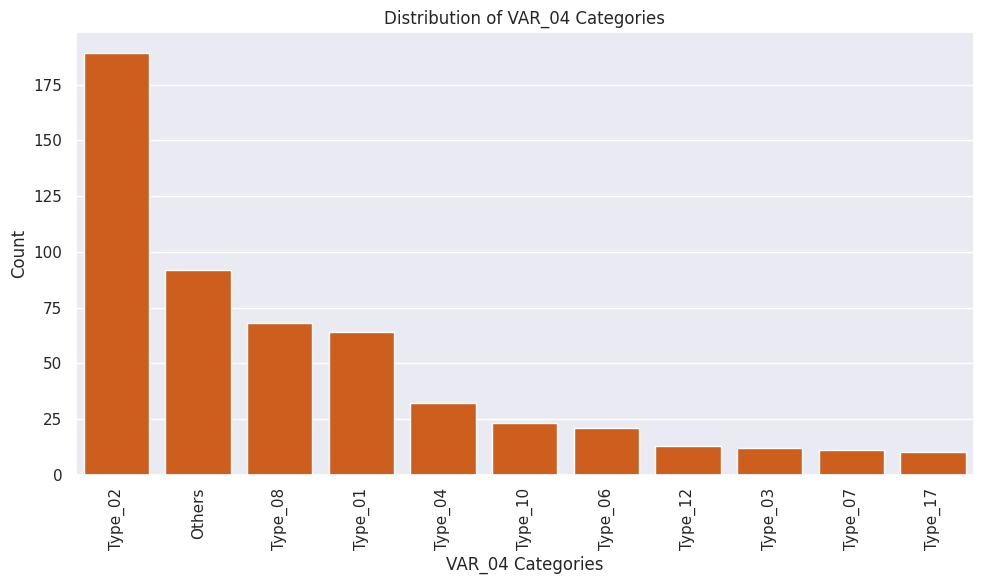

In [184]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_ob, x='VAR_04', order=df_ob['VAR_04'].value_counts().index, color='#eb5600')
plt.xlabel('VAR_04 Categories')
plt.ylabel('Count')
plt.title('Distribution of VAR_04 Categories')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [185]:
df_ob['VAR_04'].value_counts()
#create a bar plot where each bin represents each class


,count
VAR_04,
Type_02,189
Others,92
Type_08,68
Type_01,64
Type_04,32
Type_10,23
Type_06,21
Type_12,13
Type_03,12


**Observations**      
There is a disproportional quantity of data points in each class, with the Type_02 class having the most data points.

**Conclusion**          
Since the problem we are solving is a regression problem, the imbalance class may not have a direct effect on the capacity of predicting  Direct Hours. However, there is still a chance of the minority classes not being so precise, due to the lack of examples for the model to learn. This, however, is true only if the predictor VAR_04 becomes a strong predictor of Direct Hours. To mitigate any risk, a column was created to persist the number for each type. This column will be used at the Train, Test split, where we can force the algorithm to stratify both train and test accordingly, making each class have a proportional number of examples in both test and train sets, avoiding a random split, which can cause the inexistence of a particular class in the train set.

##8.Scaling

In [186]:
df_ob.head()

,DirectHours,VAR_02,VAR_03,VAR_05,VAR_06,VAR_08,VAR_09,VAR_10,VAR_11,VAR_04,SizeFlag,VAR_04_Bins
0,8.636190,0.659678,120.0,16667.86,17326.77,38.0,19288.800000000,141029.92,310179.67,Type_01,Large,1
1,6.924711,0.382512,6.0,2746.99,772.03,5.0,5079.680000000,3949.74,52035.49,Type_01,Small,1
2,8.218968,0.387494,125.0,16030.64,8711.95,31.0,4130.540000000,122317.72,180962.70,Type_02,Large,2
3,7.483059,0.286059,72.0,6892.49,3021.78,13.0,51.000000000,27087.28,61689.56,Type_02,Small,2
4,6.732211,0.491948,6.0,0.00,0.00,1.0,1.260000000,3949.74,246.09,Type_02,Small,2


**Observations**   
Given that the numerical variables range across multiple decimal cases, e.g., VAR_09 = 19288.80, and VAR_02 = 0.65. Scaling is recommended because it allows all numbers to be used on a similar scale, e.g., 0 to 1, using a technique called the Min-Max Scale. One of the main reasons to scale the data as described is that machine learning models are biased towards large values; therefore, differences in decimals are not treated equally, which can lead to poor generalization or performance.